# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Marcus Teoh Zhoon Ye (2503577E)


**Use of Generative AI tools**

# Libraries

In [1]:
## Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# One seed reused everywhere (splits, model init, CV, search) so that every number in
# this notebook is reproducible by the marker on a fresh run.
RANDOM_STATE = 42

# Show all columns; the dataset is only 12 wide so nothing needs truncating.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Consistent plot styling so every figure in the notebook reads as one report.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

print('pandas', pd.__version__, '| numpy', np.__version__)


pandas 3.0.3 | numpy 2.5.0


**Why this problem is worth solving**

A retail chain does not make one decision about a product, it makes one decision about a product per store. The same box of snack foods that sells briskly in a Tier 1 supermarket
may sit on the shelf in a Tier 3 grocery store until it is written off.

Chain-level totals
hide exactly the variation that inventory allocation depends on, which is why the unit of
prediction here is the product-outlet pair rather than the product.

Without a model, the practical fallback is to plan against an average, ordering roughly the
same quantity everywhere, then correct after the fact from what actually sold. That is the
naive baseline in Section 6, and it is a genuinely poor one: predicting the mean for every
row gives an R² of approximately zero and a typical miss of NPR 1,322 per decision.

A useful model changes what the planner can do before the selling period, not after it: it
supports how much stock to send to each outlet, which product categories earn their shelf
space, and which store formats justify further investment. It does not tell the chain
what to charge, what to promote, or how a store will perform after a refit, the dataset
contains no promotion calendar, no footfall and no competitor pricing, so those questions
sit outside what this model can honestly answer.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame

df = pd.read_csv('data/bigmart.csv')

print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()


Rows: 8,523   Columns: 12


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


The dataset is the BigMart Sales dataset, a Kaggle mirror of the Analytics Vidhya practice problem. It holds 8,523 rows and 12 columns, which is 11 candidate features plus 1 target.

Each row is one product observed at one outlet. That is exactly the unit of the business decision above.

**Column meanings**

| Column | Meaning | Level |
|---|---|---|
| `Item_Identifier` | Product code (e.g. FDA15) | Product |
| `Item_Weight` | Product weight | Product |
| `Item_Fat_Content` | Low Fat / Regular | Product |
| `Item_Visibility` | Share of total display area given to this product | Product x Outlet |
| `Item_Type` | Product category (16 levels) | Product |
| `Item_MRP` | Maximum retail price | Product |
| `Outlet_Identifier` | Store code (10 stores) | Outlet |
| `Outlet_Establishment_Year` | Year store opened | Outlet |
| `Outlet_Size` | Small / Medium / High | Outlet |
| `Outlet_Location_Type` | Tier 1 / 2 / 3 city | Outlet |
| `Outlet_Type` | Grocery Store / Supermarket Type1-3 | Outlet |
| `Item_Outlet_Sales` | Target: revenue for this product at this outlet | Product x Outlet |


## 2.2 Summary Statistics

### 2.2.1 Type of variable for each column

Before any cleaning we establish what each column is, because the variable type decides the preprocessing. Numeric columns need imputing and scaling. Categorical columns need imputing and encoding.

In [3]:
## Understand the type of variable for each column

df.info()

# Cardinality matters as much as dtype here: a column stored as 'object' with 1,559
# distinct values is an identifier, not a usable category, and must be treated differently.
print('\nDistinct values per column:')
print(df.nunique().sort_values(ascending=False).to_string())


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB

Distinct values per column:
Item_Visibility              7880

### 2.2.2 Check for missing data

Missing values decide two things. First, whether a column is usable at all. Second, whether the imputation must be fitted on the training set only, which it must be, because otherwise test-set information leaks into training.

In [4]:
## Check for missing data

missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
})
missing = missing[missing['n_missing'] > 0].sort_values('n_missing', ascending=False)

print('Columns with missing values:')
print(missing.to_string() if len(missing) else 'None')


Columns with missing values:
             n_missing  pct_missing
Outlet_Size       2410         28.3
Item_Weight       1463         17.2


### 2.2.3 Describe data distribution

Summary statistics for the numeric columns, including the target. We are looking for impossible values (a zero where zero cannot occur), and for skew in the target that would affect which error metric is honest.

In [5]:
## Describe data distribution

display(df.describe().T)

# The target deserves its own read: mean vs median tells us about skew, which affects
# both metric choice (Section 6) and whether a log transform is worth testing.
target = df['Item_Outlet_Sales']
print('Target: Item_Outlet_Sales')
print(f'  min     NPR {target.min():,.2f}')
print(f'  median  NPR {target.median():,.2f}')
print(f'  mean    NPR {target.mean():,.2f}')
print(f'  max     NPR {target.max():,.2f}')
print(f'  skew    {target.skew():.2f}   (0 = symmetric; > 1 = strong right tail)')


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


Target: Item_Outlet_Sales
  min     NPR 33.29
  median  NPR 1,794.33
  mean    NPR 2,181.29
  max     NPR 13,086.96
  skew    1.18   (0 = symmetric; > 1 = strong right tail)


### 2.2.4 Categorical levels, label consistency check

(Added subsection.) `df.info()` cannot tell us whether a categorical column uses consistent labels. If the same real-world category is spelled three different ways, one-hot encoding will create three separate columns for it and split the signal.

In [6]:
## Inspect every level of every categorical column

# pandas 3 stores text columns as the dedicated 'str' dtype, so select on that
# rather than the legacy 'object' alias (which now raises a deprecation warning).
categorical_cols = df.select_dtypes(include='str').columns

for col in categorical_cols:
    # Skip the two identifier columns - listing 1,559 product codes is not informative.
    if df[col].nunique() > 20:
        print(f'{col}: {df[col].nunique()} distinct values (identifier - not listed)\n')
        continue
    print(f'{col}  ({df[col].nunique()} levels)')
    print(df[col].value_counts().to_string())
    print()


Item_Identifier: 1559 distinct values (identifier - not listed)

Item_Fat_Content  (5 levels)
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112

Item_Type  (16 levels)
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64

Outlet_Identifier  (10 levels)
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528

Outlet_Size  (3 levels)
Outlet_Size
Medium    2793
Small     2388
High       932

Outlet_Location_Type  

### 2.2.5 Disguised missing values in `Item_Visibility`

(Added subsection.) `Item_Visibility` is the share of display area a product occupies. A product that is stocked and recorded as sold cannot occupy 0% of the shelf.

Any zero here is therefore a missing value written as a number. It is the kind that `isna()` will never flag, and it silently drags the feature's distribution toward zero.

In [7]:
## Quantify the disguised-missing problem in Item_Visibility

n_zero = (df['Item_Visibility'] == 0).sum()
print(f'Rows with Item_Visibility == 0 : {n_zero:,}  ({n_zero / len(df) * 100:.1f}%)')

# Proof that these are not genuine zeros: the products concerned still recorded sales.
zero_rows = df[df['Item_Visibility'] == 0]
print(f'...of those, rows with sales > 0 : {(zero_rows["Item_Outlet_Sales"] > 0).sum():,}')
print(f'   their median sales           : NPR {zero_rows["Item_Outlet_Sales"].median():,.2f}')
print(f'   median sales, all other rows : '
      f'NPR {df.loc[df["Item_Visibility"] > 0, "Item_Outlet_Sales"].median():,.2f}')


Rows with Item_Visibility == 0 : 526  (6.2%)
...of those, rows with sales > 0 : 526
   their median sales           : NPR 1,774.02
   median sales, all other rows : NPR 1,794.33


### 2.2.6 Identifier columns and the leakage risk they carry

(Added subsection.) `Outlet_Identifier` has only 10 levels, so it is tempting to one-hot encode it. The check below shows why that is a trap for this business problem. The 10 stores have very different average sales, so the identifier would let the model memorise each store's historical average instead of learning why stores differ, whether that is size, type, location or age.

That distinction matters commercially. A model keyed to store IDs cannot answer "what would a new Tier-2 supermarket sell?", which is the outlet-strategy question in Section 1.

In [8]:
## Why Outlet_Identifier is excluded despite having only 10 levels

outlet_profile = (
    df.groupby('Outlet_Identifier')
      .agg(n_rows=('Item_Outlet_Sales', 'size'),
           mean_sales=('Item_Outlet_Sales', 'mean'),
           outlet_type=('Outlet_Type', 'first'),
           outlet_size=('Outlet_Size', lambda s: s.iloc[0] if s.notna().any() else 'missing'),
           location=('Outlet_Location_Type', 'first'))
      .sort_values('mean_sales', ascending=False)
      .round(1)
)
display(outlet_profile)

# If mean sales are almost perfectly explained by Outlet_Type, then Outlet_Type carries
# the same signal in a form that generalises to outlets the model has never seen.
print('Mean sales by Outlet_Type (the generalisable version of the same signal):')
print(df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().round(1).to_string())


,n_rows,mean_sales,outlet_type,outlet_size,location
Outlet_Identifier,,,,,
OUT027,935,3694.0,Supermarket Type3,Medium,Tier 3
OUT035,930,2438.8,Supermarket Type1,Small,Tier 2
OUT049,930,2348.4,Supermarket Type1,Medium,Tier 1
OUT017,926,2340.7,Supermarket Type1,missing,Tier 2
OUT013,932,2299.0,Supermarket Type1,High,Tier 3
OUT046,930,2277.8,Supermarket Type1,Small,Tier 1
OUT045,929,2192.4,Supermarket Type1,missing,Tier 2
OUT018,928,1995.5,Supermarket Type2,Medium,Tier 3
OUT019,528,340.3,Grocery Store,Small,Tier 1


Mean sales by Outlet_Type (the generalisable version of the same signal):
Outlet_Type
Grocery Store         339.8
Supermarket Type1    2316.2
Supermarket Type2    1995.5
Supermarket Type3    3694.0


### 2.2.7 Is the missing data actually random?

(Added subsection.) Standard practice is to impute a missing category with its mode. That is only defensible if the values are missing more or less at random. Before accepting it, we check where the missingness sits, because if it is concentrated in a few outlets, the mode is imputing a fact about other stores onto stores it does not describe.

The same question applies to `Item_Weight`. Is a product's weight missing at random, or missing for particular products? If it is the latter, another row for the same product may carry the true weight, and a per-product lookup beats a global median.

In [9]:
## Where does the missingness actually sit?

# Outlet_Size: count missing rows per outlet. If whole outlets are missing, the
# missingness is structural (an unrecorded store attribute), not random noise.
size_missing = (
    df.assign(size_missing=df['Outlet_Size'].isna())
      .groupby('Outlet_Identifier')
      .agg(n_rows=('size_missing', 'size'),
           n_missing=('size_missing', 'sum'),
           outlet_type=('Outlet_Type', 'first'),
           location=('Outlet_Location_Type', 'first'))
)
print('Outlet_Size missingness by outlet (only outlets with any missing shown):')
print(size_missing[size_missing['n_missing'] > 0].to_string())
print(f"\nOutlets fully missing a size: "
      f"{(size_missing['n_missing'] == size_missing['n_rows']).sum()} of {len(size_missing)}")

# Item_Weight: is the weight recoverable from another row for the SAME product?
weight_by_item = df.groupby('Item_Identifier')['Item_Weight'].nunique(dropna=True)
items_missing = df.loc[df['Item_Weight'].isna(), 'Item_Identifier'].unique()
recoverable = sum(weight_by_item.get(i, 0) > 0 for i in items_missing)
print(f'\nProducts with a missing weight somewhere : {len(items_missing):,}')
print(f'...of which the weight IS recorded on another row : {recoverable:,}')
print(f'Max distinct weights recorded for any one product : {weight_by_item.max()} '
      f'(1 = weight is a stable product attribute)')


Outlet_Size missingness by outlet (only outlets with any missing shown):


                   n_rows  n_missing        outlet_type location
Outlet_Identifier                                               
OUT010                555        555      Grocery Store   Tier 3
OUT017                926        926  Supermarket Type1   Tier 2
OUT045                929        929  Supermarket Type1   Tier 2

Outlets fully missing a size: 3 of 10

Products with a missing weight somewhere : 1,142
...of which the weight IS recorded on another row : 1,138
Max distinct weights recorded for any one product : 1 (1 = weight is a stable product attribute)


### Data-quality findings and the resulting cleaning plan

| # | Issue | Column | Size | Fix | Deterministic or fitted? |
|---|---|---|---|---|---|
| 1 | Five spellings for two real categories | `Item_Fat_Content` | 545 rows (`LF` 316, `reg` 117, `low fat` 112) | Map `LF` and `low fat` to `Low Fat`, `reg` to `Regular` | Deterministic. A fixed relabelling that needs no statistic |
| 2 | Zeros that actually mean "not recorded" | `Item_Visibility` | 526 rows (6.2%) | Convert `0` to `NaN`, then impute the median | Both. The conversion is deterministic, the median that fills it is fitted |
| 3 | Missing values | `Item_Weight` | 1,463 rows (17.2%) | Look up the same product's weight from another row, falling back to the global median | Fitted. The lookup table and the fallback median are learned from the training split |
| 4 | Missing values | `Outlet_Size` | 2,410 rows (28.3%) | Label as an explicit `Unknown` category | Deterministic. Assigning a label invents no measurement |
| 5 | High-cardinality identifiers | `Item_Identifier` (1,559), `Outlet_Identifier` (10) | all rows | Drop from the model. `Item_Identifier` is retained only to drive the weight lookup | Deterministic. A fixed column selection |

The issue that would most distort the model if left alone is `Item_Visibility == 0`. The other four are visible. A missing value announces itself through `isna()`, and inconsistent labels show up the moment you call `value_counts()`.

A zero does neither. It passes every null check, it is a legal value for the column's dtype, and it silently drags 6.2% of the distribution to the floor. So the imputed median, the scaler's mean and standard deviation, and any coefficient fitted on that feature are all quietly wrong, with nothing in the output to indicate it.

The deterministic and fitted split is not a stylistic distinction, it determines where the code is allowed to live. Items 1, 4 and 5 are fixed rules and cannot leak information no matter when they run.

Items 2 and 3 depend on values computed from data, so they must sit inside the `Pipeline` and be fitted on the training split alone. Computing that median across all 8,523 rows before splitting would mean the test rows helped choose the number used to fill them.

## 2.3 Data Visualization

Everything below is plotted on the raw data, before any cleaning. That is deliberate. The plots are the evidence for the cleaning decisions taken in Section 3, so they have to show the problems rather than hide them.

### 2.3.1 Understanding distribution of data

#### 2.3.1.1 Understanding distribution of target

The shape of the target decides two later choices. Whether a log transform is worth testing, and whether RMSE, which punishes large misses quadratically, or MAE, which treats every rupee equally, is the fairer headline metric.

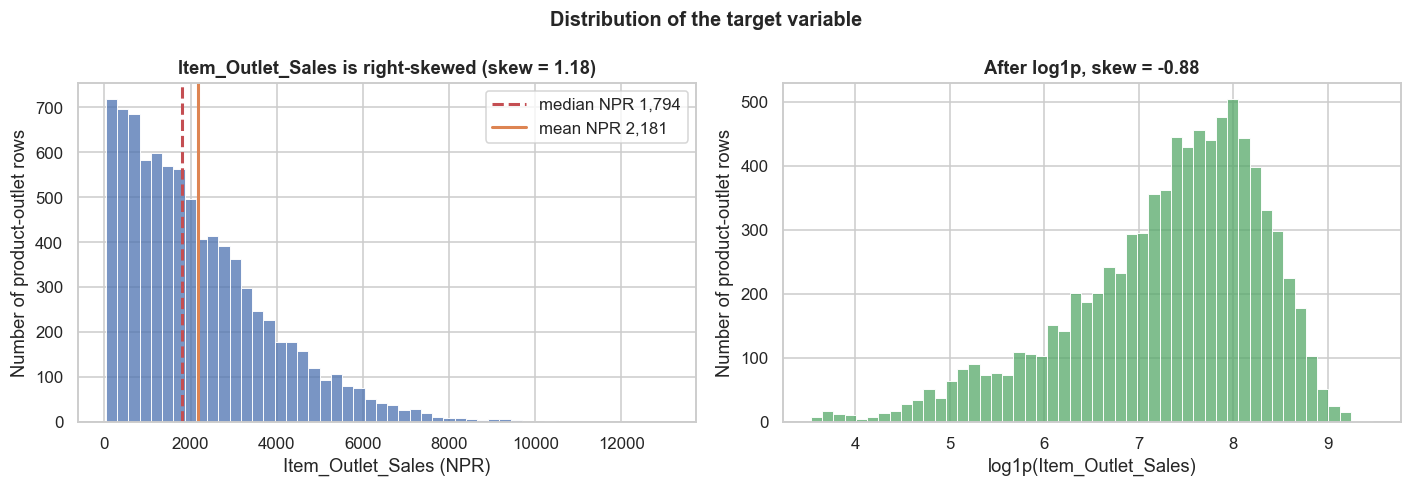

99th percentile: NPR 7,366.01   max: NPR 13,086.96
Rows above the 99th percentile: 86 (1.0%)


In [10]:
## Understanding distribution of target

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: raw target. Right: log1p, to check whether the skew is a simple scale effect.
sns.histplot(df['Item_Outlet_Sales'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].axvline(df['Item_Outlet_Sales'].median(), color='#C44E52', ls='--', lw=2,
                label=f"median NPR {df['Item_Outlet_Sales'].median():,.0f}")
axes[0].axvline(df['Item_Outlet_Sales'].mean(), color='#DD8452', ls='-', lw=2,
                label=f"mean NPR {df['Item_Outlet_Sales'].mean():,.0f}")
axes[0].set_title(f"Item_Outlet_Sales is right-skewed (skew = {df['Item_Outlet_Sales'].skew():.2f})")
axes[0].set_xlabel('Item_Outlet_Sales (NPR)')
axes[0].set_ylabel('Number of product-outlet rows')
axes[0].legend()

sns.histplot(np.log1p(df['Item_Outlet_Sales']), bins=50, ax=axes[1], color='#55A868')
axes[1].set_title(f"After log1p, skew = {np.log1p(df['Item_Outlet_Sales']).skew():.2f}")
axes[1].set_xlabel('log1p(Item_Outlet_Sales)')
axes[1].set_ylabel('Number of product-outlet rows')

fig.suptitle('Distribution of the target variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify the tail rather than eyeballing it - needed to argue about outliers.
q99 = df['Item_Outlet_Sales'].quantile(0.99)
print(f"99th percentile: NPR {q99:,.2f}   max: NPR {df['Item_Outlet_Sales'].max():,.2f}")
print(f"Rows above the 99th percentile: {(df['Item_Outlet_Sales'] > q99).sum()} "
      f"({(df['Item_Outlet_Sales'] > q99).mean() * 100:.1f}%)")


**Interpretation**

The target is right-skewed, with a skew of 1.18 and the mean (NPR 2,181.29) sitting well above the median (NPR 1,794.33). Commercially this is the ordinary shape of retail revenue. Most product-outlet pairs are unremarkable, and a small number of combinations, a popular line at a high-traffic store, generate several times the typical revenue.

The top 1% of rows, 86 of them, exceed NPR 7,366, running to a maximum of NPR 13,086.96.

These are business events, not data errors. The reasons matter for what I do next. The high values are not isolated impossible readings but sit on a continuous tail, and the rows carrying them are ordinary on every other field. Section 2.3.2 shows they are concentrated in Supermarket Type3, the highest-revenue format in the chain.

Deleting them as outliers would mean deleting exactly the product-store combinations the business most wants to forecast, so I keep all 8,523 rows and use no outlier trimming anywhere in this notebook.

For metric choice, the tail cuts both ways. Being NPR 2,000 wrong on a NPR 10,000 line is a 20% error the planner can absorb. Being NPR 2,000 wrong on a NPR 200 line is a catastrophic over-order. That argues for reporting MAE, which treats every rupee the same and is not dominated by the tail.

But the amounts at risk are genuinely larger on the big lines, which argues for RMSE, because it penalises large misses quadratically. I resolve this explicitly in Section 4.1: RMSE selects the model, MAE communicates it.

#### 2.3.1.2 Understanding distribution of features

Numeric features first. We are checking for impossible values and for shapes that will need scaling before a linear model can use them fairly.

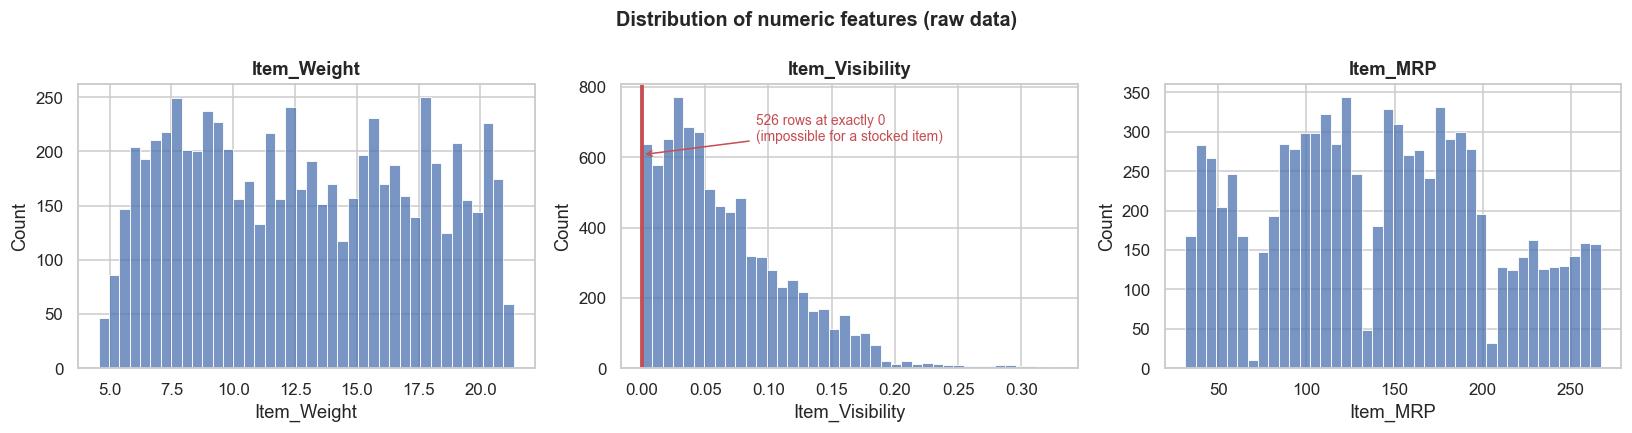

In [11]:
## Understanding distribution of numeric features

numeric_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], bins=40, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Mark the impossible-zero spike found in 2.2.5 so the problem is visible, not just stated.
n_zero = (df['Item_Visibility'] == 0).sum()
axes[1].axvline(0, color='#C44E52', lw=2.5)
axes[1].annotate(f'{n_zero} rows at exactly 0\n(impossible for a stocked item)',
                 xy=(0, axes[1].get_ylim()[1] * 0.75),
                 xytext=(0.09, axes[1].get_ylim()[1] * 0.8),
                 color='#C44E52', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='#C44E52'))

fig.suptitle('Distribution of numeric features (raw data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


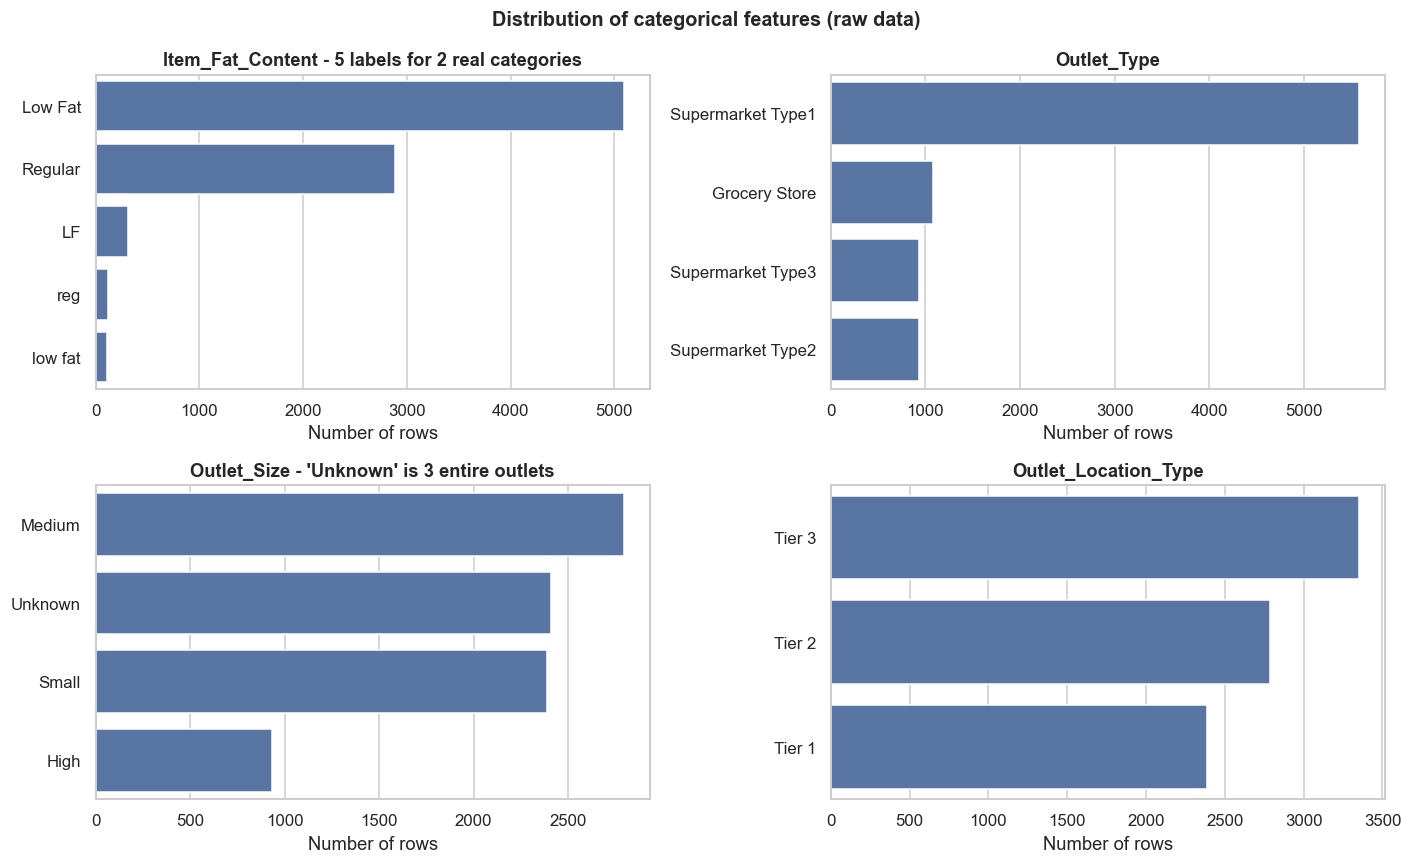

In [12]:
## Understanding distribution of categorical features

# Outlet_Size is shown with its missing values made visible rather than silently dropped,
# because 'not recorded' is itself the finding from 2.2.7.
plot_df = df.copy()
plot_df['Outlet_Size'] = plot_df['Outlet_Size'].fillna('Unknown')

cat_features = ['Item_Fat_Content', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.ravel(), cat_features):
    order = plot_df[col].value_counts().index
    sns.countplot(data=plot_df, y=col, order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('Number of rows')
    ax.set_ylabel('')

axes.ravel()[0].set_title('Item_Fat_Content - 5 labels for 2 real categories')
axes.ravel()[2].set_title("Outlet_Size - 'Unknown' is 3 entire outlets")
fig.suptitle('Distribution of categorical features (raw data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation**

**`Item_Visibility`.** The spike at exactly zero is not a genuine reading. Visibility is defined as the share of an outlet's display area a product occupies, and all 526 of these rows recorded positive sales. A product cannot sell from zero shelf space.

Their median sales (NPR 1,774.02) is essentially identical to every other row's (NPR 1,794.33), so they are not a distinct low-performing segment either. They are simply unrecorded. If left as zeros they would pull the feature's mean and standard deviation down, distorting the scaler and any coefficient fitted on it, while passing every null check silently.

**`Item_MRP`.** The distribution is not one smooth population, it separates into roughly four price bands, which becomes much clearer in the scatter plot in Section 2.3.2. This matters for model choice. A linear model fits one slope through all four bands, whereas a tree can split between them. It is a reason to expect tree-based models to have an edge here, and Section 5 bears that out, though modestly: Gradient Boosting R² 0.607 against Linear Regression's 0.579.

**`Item_Fat_Content`.** Five labels for two real categories. Left as-is, one-hot encoding would create five columns, splitting `Low Fat` across three of them and `Regular` across two. The model would then have to learn the same relationship several times from fragments of the data instead of once from all of it.

**Class balance across `Outlet_Type`.** Supermarket Type1 holds 5,577 rows (65%) while Supermarket Type2 and Type3 have roughly 930 each. No level is rare enough to be unusable, but the imbalance is worth noting because Supermarket Type3 is the highest-revenue format in the chain. The model has the least evidence about the outlets that matter most per transaction. This is visible later in Section 7.4, where Type3 carries the largest absolute error of any segment.

### 2.3.2 Understanding relationship between variables

Distribution tells us what each column is. This section asks which columns actually move revenue. That ranking is what drives feature selection in Section 4.

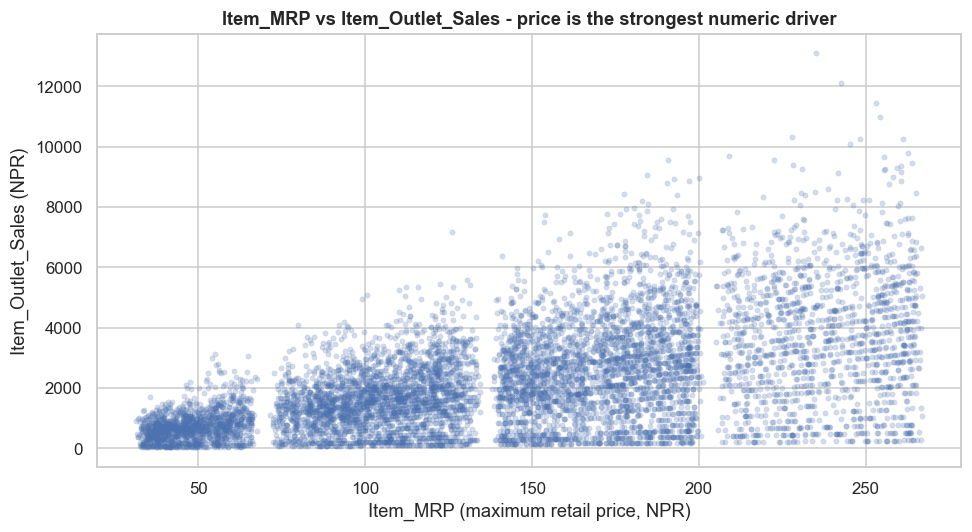

Pearson correlation, Item_MRP vs Item_Outlet_Sales: 0.568


In [13]:
## Relationship: Item_MRP vs Item_Outlet_Sales

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales',
                alpha=0.25, s=12, ax=ax, color='#4C72B0', edgecolor=None)
ax.set_title('Item_MRP vs Item_Outlet_Sales - price is the strongest numeric driver')
ax.set_xlabel('Item_MRP (maximum retail price, NPR)')
ax.set_ylabel('Item_Outlet_Sales (NPR)')
plt.tight_layout()
plt.show()

r = df['Item_MRP'].corr(df['Item_Outlet_Sales'])
print(f'Pearson correlation, Item_MRP vs Item_Outlet_Sales: {r:.3f}')


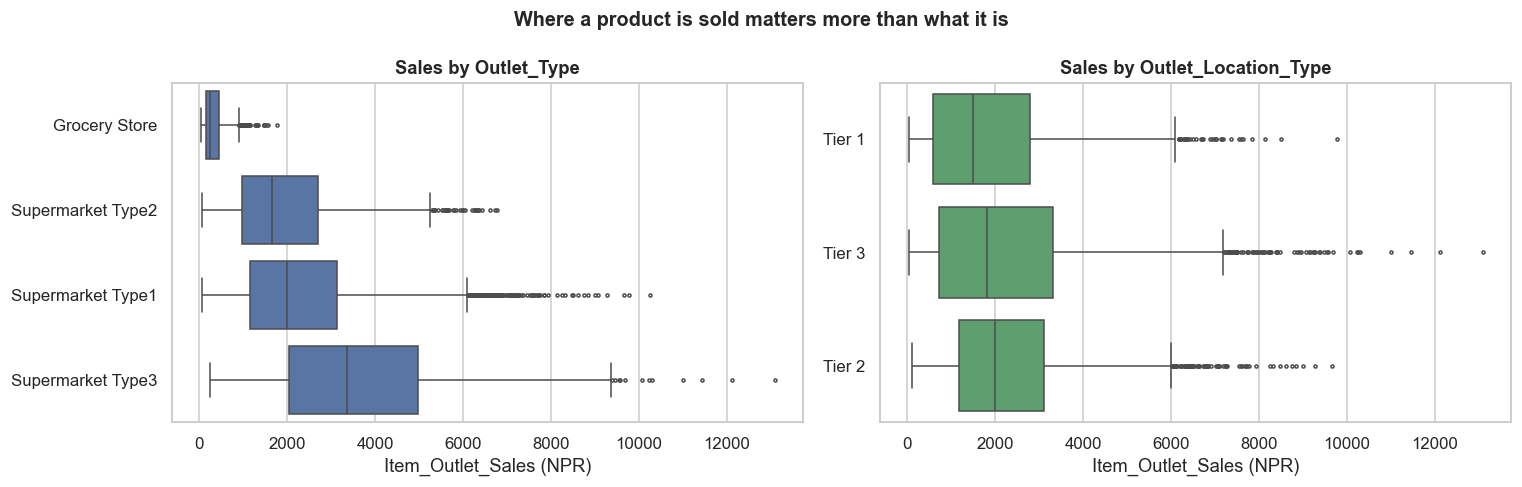

Median sales by Outlet_Type:
                   count  median    mean
Outlet_Type                             
Grocery Store       1083   257.0   339.8
Supermarket Type1   5577  1990.7  2316.2
Supermarket Type2    928  1655.2  1995.5
Supermarket Type3    935  3365.0  3694.0


In [14]:
## Relationship: sales by outlet attributes

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order_type = df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Type', order=order_type,
            ax=axes[0], color='#4C72B0', fliersize=2)
axes[0].set_title('Sales by Outlet_Type')
axes[0].set_xlabel('Item_Outlet_Sales (NPR)')
axes[0].set_ylabel('')

order_loc = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Location_Type', order=order_loc,
            ax=axes[1], color='#55A868', fliersize=2)
axes[1].set_title('Sales by Outlet_Location_Type')
axes[1].set_xlabel('Item_Outlet_Sales (NPR)')
axes[1].set_ylabel('')

fig.suptitle('Where a product is sold matters more than what it is',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median sales by Outlet_Type:')
print(df.groupby('Outlet_Type')['Item_Outlet_Sales'].agg(['count', 'median', 'mean'])
        .round(1).to_string())


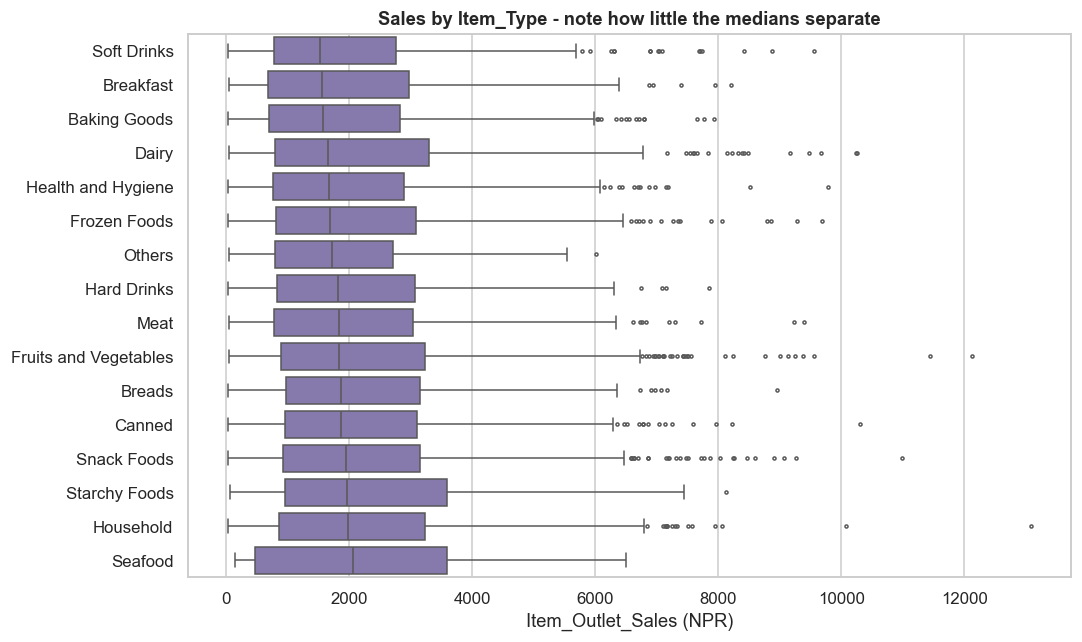

Median sales range across the 16 Item_Type levels: NPR 1,518 to NPR 2,055
Median sales range across the 4 Outlet_Type levels : NPR 257 to NPR 3,365


In [15]:
## Relationship: sales by product category

fig, ax = plt.subplots(figsize=(10, 6))
order_item = df.groupby('Item_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Item_Type', order=order_item,
            ax=ax, color='#8172B3', fliersize=2)
ax.set_title('Sales by Item_Type - note how little the medians separate')
ax.set_xlabel('Item_Outlet_Sales (NPR)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

spread = df.groupby('Item_Type')['Item_Outlet_Sales'].median()
print(f'Median sales range across the 16 Item_Type levels: '
      f'NPR {spread.min():,.0f} to NPR {spread.max():,.0f}')
print(f'Median sales range across the 4 Outlet_Type levels : '
      f"NPR {df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().min():,.0f} to "
      f"NPR {df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().max():,.0f}")


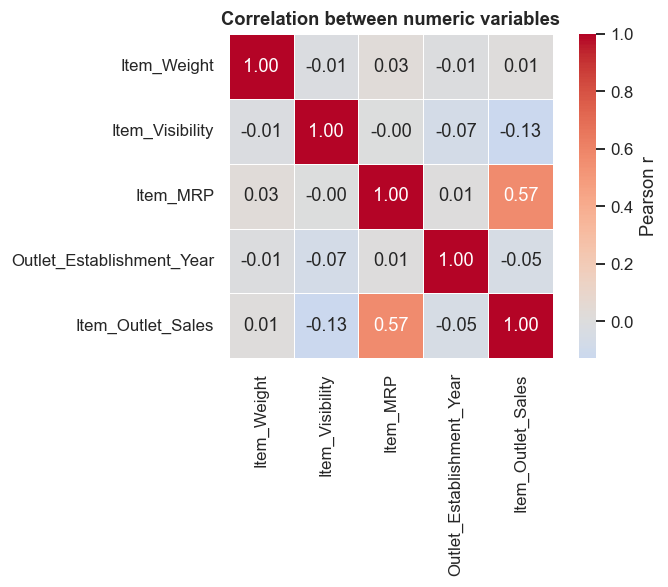

Correlation with the target, strongest first:
Item_MRP                     0.568
Item_Visibility             -0.129
Outlet_Establishment_Year   -0.049
Item_Weight                  0.014


In [16]:
## Correlation between numeric variables

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation between numeric variables', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with the target, strongest first:')
print(corr['Item_Outlet_Sales'].drop('Item_Outlet_Sales')
          .sort_values(key=abs, ascending=False).round(3).to_string())


#### 2.3.2.1 Ranking every feature by how much of the sales variance it explains

(Added subsection.) Pearson correlation only works for numeric columns, so it cannot compare `Item_MRP` against `Outlet_Type`. Eta-squared can. It is the share of total sales variance that lies between a column's groups rather than within them, on the same 0 to 1 scale for numeric and categorical features alike. This gives one honest ranking to justify feature selection in Section 4.

,feature,kind,eta_squared
0,Item_MRP,numeric (binned),0.3189
1,Outlet_Type,categorical,0.2396
2,Outlet_Establishment_Year,numeric (binned),0.0871
3,Outlet_Size,categorical,0.0482
4,Item_Visibility,numeric (binned),0.0173
5,Outlet_Location_Type,categorical,0.0125
6,Item_Type,categorical,0.0047
7,Item_Weight,numeric (binned),0.0015
8,Item_Fat_Content,categorical,0.0004


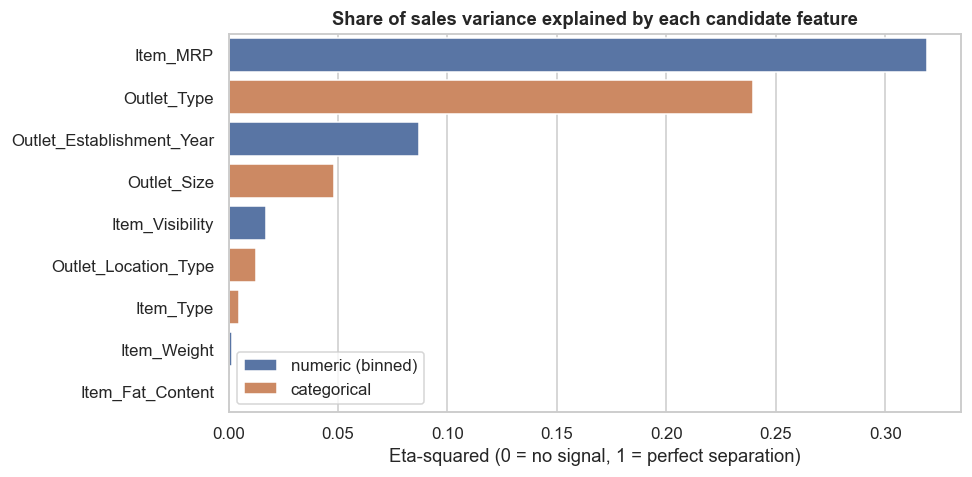

In [17]:
## Rank all candidate features by variance explained (eta-squared)

def eta_squared(frame, feature, target='Item_Outlet_Sales'):
    """Share of total variance in `target` explained by group membership in `feature`.

    0 = the groups all have the same mean (no signal);
    1 = every group is internally identical (perfect separation).
    """
    groups = frame.groupby(feature, observed=True)[target]
    grand_mean = frame[target].mean()
    ss_between = (groups.count() * (groups.mean() - grand_mean) ** 2).sum()
    ss_total = ((frame[target] - grand_mean) ** 2).sum()
    return ss_between / ss_total

# Descriptive only: the two deterministic fixes are applied to a COPY so the ranking is
# not distorted by split labels. The real transformation is defined in Section 3 and
# lives inside the pipeline, never as a mutation of `df`.
tidy = df.copy()
tidy['Item_Fat_Content'] = tidy['Item_Fat_Content'].replace(
    {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})
tidy['Outlet_Size'] = tidy['Outlet_Size'].fillna('Unknown')

# Numeric features are binned into deciles so the same statistic applies to every column.
rows = []
for col in ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']:
    rows.append({'feature': col, 'kind': 'categorical',
                 'eta_squared': eta_squared(tidy, col)})

for col in ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']:
    binned = tidy.assign(_bin=pd.qcut(tidy[col], 10, duplicates='drop'))
    rows.append({'feature': col, 'kind': 'numeric (binned)',
                 'eta_squared': eta_squared(binned.dropna(subset=['_bin']), '_bin')})

signal = (pd.DataFrame(rows)
            .sort_values('eta_squared', ascending=False)
            .reset_index(drop=True))
signal['eta_squared'] = signal['eta_squared'].round(4)
display(signal)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=signal, x='eta_squared', y='feature', hue='kind',
            dodge=False, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Share of sales variance explained by each candidate feature',
             fontweight='bold')
ax.set_xlabel('Eta-squared (0 = no signal, 1 = perfect separation)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()


### EDA summary, implications for modelling

- Revenue is driven by the store, not the product. `Item_MRP` (η² = 0.319) and `Outlet_Type` (η² = 0.240) dominate every other feature by an order of magnitude. Median sales range from NPR 257 to NPR 3,365 across the four store formats, but only from NPR 1,518 to NPR 2,055 across all sixteen product categories. Consequence: the model's job is mostly to learn price and format, so I should expect a compact feature set to perform close to the full one. That is a hypothesis I test directly in Section 3.5 rather than assume.

- `Item_Type` costs 16 one-hot columns and returns η² = 0.005. Consequence: it is a candidate for removal on evidence, not a feature to keep out of habit. It also cannot be dropped purely on this statistic, because η² measures each feature alone and ignores interactions. That is why the decision is made by cross-validated error in Section 3.5.

- `Item_MRP` separates into roughly four price bands rather than one cloud, with a correlation to the target of 0.568. Consequence: a single linear coefficient must average across the bands, whereas a tree can split between them. This is a concrete reason to include tree-based models in the comparison and not stop at Linear Regression.

- `Outlet_Establishment_Year` carries real signal (η² = 0.087) but only as a raw label. Consequence: convert it to `Outlet_Age`, years trading as at 2013. Age is monotonic and is the quantity a planner actually reasons about, so a linear model can use it directly, whereas a calendar year is an arbitrary integer.

- The target has a genuine right tail, with a skew of 1.18 and the top 1% above NPR 7,366. Consequence: no outlier trimming, because these are the chain's best-performing lines. RMSE will run above MAE throughout, so I report both and lead with MAE when speaking to the business.

- The dataset has no footfall, promotion calendar, competitor pricing or stock-on-hand. Consequence: there is a ceiling on achievable accuracy that no algorithm can lift, so I should judge the final model against the naive baseline rather than against R² = 1. Two identical products on all nine available fields genuinely sold different amounts, and nothing in this data can resolve that.

# 3. Data Preparation

## 3.1 Data Cleaning

Every cleaning rule below is classified as deterministic or fitted, because that classification decides where the code is allowed to live.

| Kind | Definition | Where it must run |
|---|---|---|
| Deterministic | A fixed rule needing no statistic from the data, e.g. `LF` to `Low Fat` | Anywhere, because it cannot leak |
| Fitted | Needs a value learned from data, e.g. a median or a category list | Inside the `Pipeline`, fitted on the training split only |

Getting this wrong is the single most common way to produce an inflated score. Computing a median over all 8,523 rows and then splitting means the test rows helped choose the value used to fill them. We quantify that effect in Section 7.

### 3.1.1 Evidence for the non-edible rule

Section 2.2.4 showed all `Item_Fat_Content` values collapse to `Low Fat` or `Regular`. But the `Item_Identifier` prefix encodes something the fat label ignores: `FD` is food, `DR` is drink, `NC` is non-consumable. Calling a household cleaning product "Low Fat" is meaningless, and it lets the encoder treat soap and yoghurt as the same kind of thing.

The check below decides which column the rule should key off. The Streamlit app collects `Item_Type` but has no product code, so if `Item_Type` identifies the non-consumables exactly, the rule works identically in training and in the app.

In [18]:
## Does Item_Type identify the non-consumables exactly?

prefix = df['Item_Identifier'].str[:2]
crosstab = pd.crosstab(df['Item_Type'], prefix)
display(crosstab)

nc_types = sorted(crosstab.index[crosstab['NC'] > 0].tolist())
# 'Exclusive' means those Item_Types contain NC rows and nothing else - if so, the
# mapping is one-to-one and Item_Type is a safe substitute for the identifier prefix.
exclusive = crosstab.loc[nc_types].drop(columns='NC').to_numpy().sum() == 0

print(f'Item_Types under the NC prefix : {nc_types}')
print(f'Are those types exclusively NC? : {exclusive}')
print(f'Rows affected                   : {(prefix == "NC").sum():,}')
print('\nFat content currently recorded on those non-consumable rows:')
print(df.loc[prefix == 'NC', 'Item_Fat_Content'].value_counts().to_string())


Item_Identifier,DR,FD,NC
Item_Type,,,
Baking Goods,0,648,0
Breads,0,251,0
Breakfast,0,110,0
Canned,0,649,0
Dairy,140,542,0
Frozen Foods,0,856,0
Fruits and Vegetables,0,1232,0
Hard Drinks,214,0,0
Health and Hygiene,0,0,520


Item_Types under the NC prefix : ['Health and Hygiene', 'Household', 'Others']
Are those types exclusively NC? : True
Rows affected                   : 1,599

Fat content currently recorded on those non-consumable rows:
Item_Fat_Content
Low Fat    1477
LF           94
low fat      28


### 3.1.2 The preprocessing module

The transformations are written to `bigmart_preprocessing.py` rather than defined inline. Two reasons, both practical.

1. The Streamlit app imports this same file. Preprocessing cannot drift apart from the model, because there is only one copy of it.
2. Pickled pipelines need importable code. A transformer defined in a notebook cell cannot be reloaded by `joblib.load()` inside another process.

Note which rules are fitted. `ItemWeightImputer` builds its lookup table in `fit()`, so it only ever sees training rows.

In [19]:
%%writefile bigmart_preprocessing.py
"""Preprocessing for the BigMart sales model.

Imported by the notebook and the Streamlit app so a row is transformed identically in
training and in production. Fitted steps are transformers, so they only ever see the
training split.
"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Data collected in 2013. Age is measured against that year so the app never
# extrapolates past the oldest outlet the model saw.
DATA_YEAR = 2013

# Five spellings, two real categories (notebook 2.2.4).
FAT_CONTENT_MAP = {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}

# These three Item_Types are exactly the 'NC' non-consumable prefix (notebook 3.1.1).
# Keying off Item_Type lets the app apply the rule without a product code.
NON_EDIBLE_ITEM_TYPES = ('Health and Hygiene', 'Household', 'Others')
NON_EDIBLE_LABEL = 'Non-Edible'

# Only Item_MRP, Outlet_Type and Outlet_Age carry real signal. All nine are kept
# because notebook 3.5 measured the alternatives: CV RMSE spread 3.90 against fold
# noise of 20 to 23, so removal is a change inside the noise. Identifiers are
# excluded (notebook 2.2.6).
NUMERIC_FEATURES = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
CATEGORICAL_FEATURES = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
                        'Outlet_Location_Type', 'Outlet_Type']


def clean_deterministic(X):
    """Fixed rules that need no statistic from the data, so they cannot leak."""
    X = X.copy()

    # Collapse the five fat-content spellings into two.
    X['Item_Fat_Content'] = X['Item_Fat_Content'].replace(FAT_CONTENT_MAP)

    # Fat content is meaningless for cleaning products, so give them their own label.
    is_non_edible = X['Item_Type'].isin(NON_EDIBLE_ITEM_TYPES)
    X.loc[is_non_edible, 'Item_Fat_Content'] = NON_EDIBLE_LABEL

    # A stocked item cannot occupy 0% of the shelf, so treat zero as missing.
    X['Item_Visibility'] = X['Item_Visibility'].replace(0.0, np.nan)

    # Three outlets have no size recorded. Say so rather than invent one.
    X['Outlet_Size'] = X['Outlet_Size'].fillna('Unknown')

    # Years trading is the business quantity, and it is monotonic unlike a raw year.
    X['Outlet_Age'] = DATA_YEAR - X['Outlet_Establishment_Year']

    return X


class ItemWeightImputer(BaseEstimator, TransformerMixin):
    """Fill a missing Item_Weight from the same product's weight on another row.

    Weight is a stable product attribute, so this recovers 1,138 of the 1,142 affected
    products where a global median would not. The lookup is built in fit(), so it is
    learned from the training split only, and it is skipped when Item_Identifier is
    absent as it is in the app.
    """

    def fit(self, X, y=None):
        if 'Item_Identifier' in X.columns:
            self.weight_by_item_ = (
                X.groupby('Item_Identifier')['Item_Weight'].median().dropna()
            )
        else:
            self.weight_by_item_ = pd.Series(dtype=float)
        self.global_median_ = X['Item_Weight'].median()
        return self

    def transform(self, X):
        X = X.copy()
        if 'Item_Identifier' in X.columns and len(self.weight_by_item_):
            recovered = X['Item_Identifier'].map(self.weight_by_item_)
            X['Item_Weight'] = X['Item_Weight'].fillna(recovered)
        X['Item_Weight'] = X['Item_Weight'].fillna(self.global_median_)
        return X


def build_preprocessor(numeric_features, categorical_features):
    """Impute and scale the numerics, impute and one-hot the categoricals.

    Every step is fitted, so it must sit inside the pipeline. Unnamed columns are
    dropped. StandardScaler is needed by Linear Regression and harmless to the trees.
    """
    numeric_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        # handle_unknown='ignore' stops the app crashing on an unseen category.
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        [
            ('num', numeric_pipe, list(numeric_features)),
            ('cat', categorical_pipe, list(categorical_features)),
        ],
        remainder='drop',
    )


def build_pipeline(model, numeric_features=NUMERIC_FEATURES,
                   categorical_features=CATEGORICAL_FEATURES):
    """The complete path from a raw BigMart row to a prediction."""
    return Pipeline([
        ('clean', FunctionTransformer(clean_deterministic, validate=False)),
        ('weight', ItemWeightImputer()),
        ('prep', build_preprocessor(numeric_features, categorical_features)),
        ('model', model),
    ])


Overwriting bigmart_preprocessing.py


In [20]:
## Import the module and confirm the cleaning rules do what 3.1.1 claimed

import importlib
import bigmart_preprocessing as bp
importlib.reload(bp)  # picks up the file just written, even on a re-run

cleaned_preview = bp.clean_deterministic(df)

print('Item_Fat_Content BEFORE cleaning:')
print(df['Item_Fat_Content'].value_counts().to_string())
print('\nItem_Fat_Content AFTER cleaning:')
print(cleaned_preview['Item_Fat_Content'].value_counts().to_string())

print(f"\nItem_Visibility zeros  before: {(df['Item_Visibility'] == 0).sum():,}"
      f"   after: {(cleaned_preview['Item_Visibility'] == 0).sum():,}"
      f"   (now NaN: {cleaned_preview['Item_Visibility'].isna().sum():,})")
print(f"Outlet_Size missing    before: {df['Outlet_Size'].isna().sum():,}"
      f"   after: {cleaned_preview['Outlet_Size'].isna().sum():,}"
      f"   ('Unknown': {(cleaned_preview['Outlet_Size'] == 'Unknown').sum():,})")
print(f"Outlet_Age created     range : {cleaned_preview['Outlet_Age'].min()}"
      f" to {cleaned_preview['Outlet_Age'].max()} years")


Item_Fat_Content BEFORE cleaning:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112

Item_Fat_Content AFTER cleaning:
Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599

Item_Visibility zeros  before: 526   after: 0   (now NaN: 526)
Outlet_Size missing    before: 2,410   after: 0   ('Unknown': 2,410)
Outlet_Age created     range : 4 to 28 years


## 3.2 Feature Engineering

`Outlet_Age` is 2013 minus `Outlet_Establishment_Year`. The raw year is a label, the age is a quantity. A planner asks how long a store has been trading, not whether it opened in 1997. Age is also monotonic, so a linear model can actually use it.

A feature deliberately not built is `Item_Category`, meaning Food, Drink or Non-Consumable taken from the identifier prefix. It is a strict coarsening of `Item_Type`, which is already encoded, so it can carry no information `Item_Type` lacks. The granularity question it would answer is tested directly in Section 3.5 instead, by removing `Item_Type` altogether.

,n_rows,mean_sales,outlet_types
Outlet_Age,,,
4,928,1995.5,1
6,926,2340.7,1
9,930,2438.8,1
11,929,2192.4,1
14,930,2348.4,1
15,555,339.4,1
16,930,2277.8,1
26,932,2299.0,1
28,1463,2483.7,2


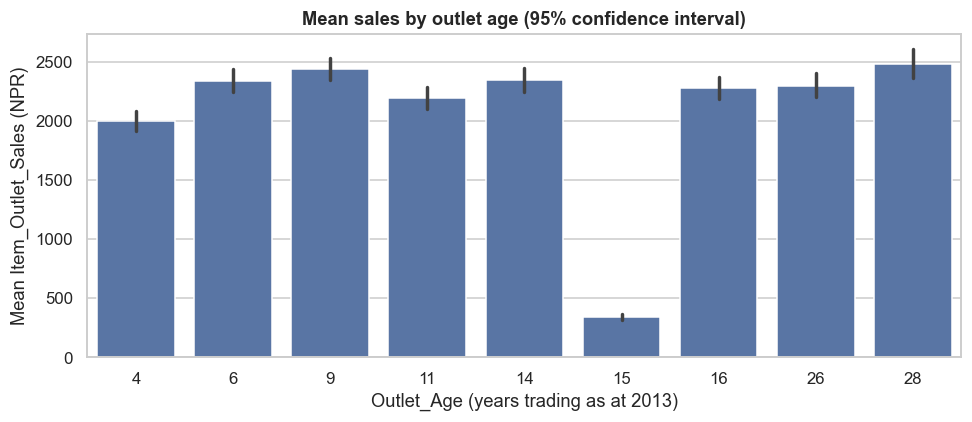

In [21]:
## Does Outlet_Age carry signal, and is it better behaved than the raw year?

age_profile = (cleaned_preview
               .groupby('Outlet_Age')
               .agg(n_rows=('Item_Outlet_Sales', 'size'),
                    mean_sales=('Item_Outlet_Sales', 'mean'),
                    outlet_types=('Outlet_Type', lambda s: s.nunique()))
               .round(1))
display(age_profile)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=cleaned_preview, x='Outlet_Age', y='Item_Outlet_Sales',
            errorbar=('ci', 95), ax=ax, color='#4C72B0')
ax.set_title('Mean sales by outlet age (95% confidence interval)', fontweight='bold')
ax.set_xlabel('Outlet_Age (years trading as at 2013)')
ax.set_ylabel('Mean Item_Outlet_Sales (NPR)')
plt.tight_layout()
plt.show()


**Interpretation, and a confounder worth naming before someone else does**

The relationship is not monotonic, and the apparent pattern is misleading. Outlet age 15 shows mean sales of NPR 339.40 against roughly NPR 2,300 for every other age group. That collapse looks dramatic until you read the `outlet_types` column: the bucket contains 555 rows from a single outlet, and that outlet is a Grocery Store. The age-28 bucket, by contrast, holds 1,463 rows spanning two different formats.

So the effect is store format, not store age. Grocery Stores average NPR 339.80 across the whole dataset, which is almost exactly the figure attributed here to age 15. Because there are only ten outlets and each has exactly one establishment year, `Outlet_Age` is almost perfectly confounded with outlet identity, and therefore with `Outlet_Type`, `Outlet_Size` and `Outlet_Location_Type`.

Two consequences follow. First, I keep `Outlet_Age` as a feature, because it is legitimately predictive and the permutation importance in Section 7.2 confirms it contributes, with an RMSE increase of NPR 28.61 when shuffled.

Second, I will not claim that outlets sell more as they age. With ten outlets and one year each, this dataset cannot separate the effect of age from the effect of the format that happens to occupy that age. Answering that question would need several outlets of each format at each age, which is a data-collection problem rather than a modelling one.

## 3.3 Train-Test Split

The split happens before anything is fitted. From here on, `X_test` is untouchable. It is looked at exactly once, in Section 7, to report the final honest score.

80/20 with a fixed seed. `Item_Identifier` is kept in `X` so `ItemWeightImputer` can use it. The `ColumnTransformer` drops it before it ever reaches a model.

In [22]:
## Split data into train set and test set

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')
print(f'Train mean sales: NPR {y_train.mean():,.2f}   Test mean sales: NPR {y_test.mean():,.2f}')
# The two means should be close; a large gap would mean the split happened to be unlucky
# and every downstream comparison would be measuring that instead of model quality.
print(f'Difference: NPR {abs(y_train.mean() - y_test.mean()):,.2f} '
      f'({abs(y_train.mean() - y_test.mean()) / y_train.mean() * 100:.2f}% of train mean)')


Train: 6,818 rows   Test: 1,705 rows
Train mean sales: NPR 2,202.37   Test mean sales: NPR 2,097.01
Difference: NPR 105.36 (4.78% of train mean)


## 3.4 Preprocessing Pipeline

`Pipeline` and `ColumnTransformer` together mean preprocessing travels with the model. When the Streamlit app calls `.predict()` on a raw row, the same cleaning, the same imputation values and the same encoding are applied automatically. There is no second implementation to drift out of sync.

In [23]:
## Build and inspect the pipeline

from sklearn import set_config
from sklearn.linear_model import LinearRegression

set_config(display='diagram')  # renders the pipeline as an inspectable diagram

demo_pipeline = bp.build_pipeline(LinearRegression())
demo_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...001D581FA2020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

In [24]:
## What does the data look like once it leaves the preprocessor?

# Fit on TRAIN ONLY - this is the line that keeps the evaluation honest.
demo_pipeline.fit(X_train, y_train)

encoded_names = demo_pipeline.named_steps['prep'].get_feature_names_out()
print(f'{X_train.shape[1]} raw columns -> {len(encoded_names)} model-ready features\n')
for name in encoded_names:
    print('  ', name)


11 raw columns -> 34 model-ready features

   num__Item_Weight
   num__Item_Visibility
   num__Item_MRP
   num__Outlet_Age
   cat__Item_Fat_Content_Low Fat
   cat__Item_Fat_Content_Non-Edible
   cat__Item_Fat_Content_Regular
   cat__Item_Type_Baking Goods
   cat__Item_Type_Breads
   cat__Item_Type_Breakfast
   cat__Item_Type_Canned
   cat__Item_Type_Dairy
   cat__Item_Type_Frozen Foods
   cat__Item_Type_Fruits and Vegetables
   cat__Item_Type_Hard Drinks
   cat__Item_Type_Health and Hygiene
   cat__Item_Type_Household
   cat__Item_Type_Meat
   cat__Item_Type_Others
   cat__Item_Type_Seafood
   cat__Item_Type_Snack Foods
   cat__Item_Type_Soft Drinks
   cat__Item_Type_Starchy Foods
   cat__Outlet_Size_High
   cat__Outlet_Size_Medium
   cat__Outlet_Size_Small
   cat__Outlet_Size_Unknown
   cat__Outlet_Location_Type_Tier 1
   cat__Outlet_Location_Type_Tier 2
   cat__Outlet_Location_Type_Tier 3
   cat__Outlet_Type_Grocery Store
   cat__Outlet_Type_Supermarket Type1
   cat__Outlet_Type_Supe

## 3.5 Feature Selection, decided by cross-validation rather than intuition

Section 2.3.2.1 ranked `Item_Type` (η² = 0.005), `Item_Weight` (0.001) and `Item_Fat_Content` (0.0004) as carrying almost no signal on their own. But eta-squared measures each feature in isolation. A weak feature can still earn its place through interaction with others. The only honest test is to remove them and measure what happens to cross-validated error.

Three candidate feature sets are compared with 5-fold CV on the training split only. The test set plays no part in this decision.

| Set | Features | Question it answers |
|---|---|---|
| Full | all 9 | The proposal's feature set, the incumbent |
| Lean | 6, dropping `Item_Type`, `Item_Weight` and `Item_Fat_Content` | Do the low-η² product attributes pay for themselves? |
| Minimal | 3, being `Item_MRP`, `Outlet_Type` and `Outlet_Age` | How much of the performance comes from the top three signals alone? |


In [25]:
## Compare candidate feature sets by cross-validated RMSE

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

# One fixed model and one fixed fold assignment for every candidate set, so the only
# thing changing between rows of the table is the feature list.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

feature_sets = {
    'Full (9 features)': (
        ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age'],
        ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
         'Outlet_Location_Type', 'Outlet_Type'],
    ),
    'Lean (6 features)': (
        ['Item_Visibility', 'Item_MRP', 'Outlet_Age'],
        ['Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
    ),
    'Minimal (3 features)': (
        ['Item_MRP', 'Outlet_Age'],
        ['Outlet_Type'],
    ),
}

results = []
for label, (num_f, cat_f) in feature_sets.items():
    pipe = bp.build_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE), num_f, cat_f
    )
    scores = -cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring='neg_root_mean_squared_error')
    results.append({
        'feature_set': label,
        'n_features': len(num_f) + len(cat_f),
        'cv_rmse': scores.mean(),
        'cv_std': scores.std(),
    })
    print(f'{label:<22} CV RMSE {scores.mean():>8,.1f}  +/- {scores.std():>5,.1f}')

selection = pd.DataFrame(results)
selection['vs_full'] = (selection['cv_rmse'] - selection.loc[0, 'cv_rmse']).round(1)
print()
display(selection.round(1))


Full (9 features)      CV RMSE  1,100.4  +/-  23.1


Lean (6 features)      CV RMSE  1,096.5  +/-  21.7


Minimal (3 features)   CV RMSE  1,099.3  +/-  20.1



,feature_set,n_features,cv_rmse,cv_std,vs_full
0,Full (9 features),9,1100.4,23.1,0.0
1,Lean (6 features),6,1096.5,21.7,-3.8
2,Minimal (3 features),3,1099.3,20.1,-1.1


**Decision: keep all nine features.**

The three candidate sets are statistically indistinguishable. Lean, with 6 features, scored the best cross-validated RMSE at NPR 1,096.5, ahead of Full at NPR 1,100.4 and Minimal at NPR 1,099.3. But the entire spread across the three is NPR 3.90, while the fold-to-fold standard deviation within each set is NPR 20.10 to NPR 23.10, more than five times larger.

A difference that small, measured against that much noise, is not evidence that one set is better. It is evidence that the sets are equivalent.

The striking part is the Minimal set. `Item_MRP`, `Outlet_Type` and `Outlet_Age` alone match the full nine-feature model to within NPR 1.10 of CV RMSE. That independently confirms the eta-squared ranking in Section 2.3.2.1, and it tells me something useful about where the remaining error lives. It is not caused by features I left out of the model, but by information absent from the dataset entirely.

Since the measurement does not separate the options, I break the tie on deployment grounds. I keep the full nine because they are the features my approved proposal specified, and because the Streamlit application is more useful to a category manager who can vary product type, weight and fat content and see the forecast respond. Even when that response is small, seeing it is informative.

Dropping features to save NPR 3.90 of noise would cost real interface value for no measurable accuracy gain. I am recording the comparison rather than hiding it. If this model went to production at scale, the Minimal set would be the right choice, because it needs three inputs instead of nine at no measurable cost in accuracy.

The one feature I would add if I could collect new data is footfall per outlet per period. Store format is already the second strongest predictor, and format is largely a proxy for how many people walk through the door, so measuring traffic directly would replace a proxy with the real quantity.

It is also the most realistic to obtain. Door counters are inexpensive and most chains already have them, so the cost is integration rather than new hardware. Promotion calendars would likely help more but are harder to reconstruct historically.

# 4. Modelling

## 4.1 Evaluation Metric Selection & Justification

Three metrics are reported throughout, because they answer three different questions and a retail audience needs a different one from a modeller.

| Metric | What it means here | Who it is for |
|---|---|---|
| **MAE** | "On a typical product-outlet decision we are off by NPR X" | The inventory planner. It is in rupees and it is the number they feel |
| **RMSE** | Same units, but squares the errors first, so one \NPR 3,000 miss hurts more than ten \NPR 300 misses | Model selection. It matches where the business actually loses money |
| **R²** | Share of sales variance explained, 0 to 1, unitless | Comparing against the do-nothing baseline |

**Why RMSE is the selection metric.** Retail losses are not linear in the error. A single large over-forecast on a fast-moving line ties up cash and creates waste; a single large under-forecast is a stockout that sends the customer to a competitor. Concentrated errors cost more than the same total error spread thinly, which is precisely the asymmetry RMSE encodes and MAE ignores. So RMSE drives `RandomizedSearchCV` and every model choice.

**Why MAE leads in the pitch.** "Our forecast is typically NPR X off" is a sentence a category manager can act on. RMSE is inflated by the 1% blockbuster tail found in §2.3.1.1 and overstates the error a planner experiences day to day.

> ⚖️ **This is a judgement call, and you should own it in Q&A.** The defensible opposite position: if the chain's real cost is roughly linear in units mis-forecast, MAE should select the model too, and optimising RMSE makes the model over-cautious about the rare blockbuster rows. Be ready to say which cost structure you assumed and why.

**Metric justification**

**I lead with MAE.** For an inventory planner the useful sentence is "this forecast is
typically off by about NPR 716 per product-outlet decision", and MAE is the only one of the
three metrics that means exactly that. RMSE is in the same units but is inflated by the 1%
of blockbuster rows identified in Section 2.3.1.1, so it overstates the error the planner
actually experiences on a normal line. R² is useful for one thing only, showing that the
model beats predicting the mean, and is meaningless as a rupee figure.

**But RMSE selects the model,** and it drives every cross-validation score and the
`RandomizedSearchCV` objective in Section 6. The reason is that retail losses are not linear
in the size of the error. Consider two ways to be NPR 2,000 wrong across ten products: miss by
NPR 200 on each, or be right on nine and miss by NPR 2,000 on one. MAE scores these identically.
They are not identical. Ten small misses are absorbed by normal safety stock; one NPR 2,000
miss is either a stockout that sends a customer to a competitor and may not come back, or a
pallet of unsold goods tying up cash and, for perishables, heading for write-off. Errors
that concentrate cost more than errors that spread, and RMSE is the metric that encodes
that asymmetry.

**The assumption I am making** is that the cost of a forecast error is convex, that it grows
faster than proportionally with the size of the miss. That holds when stockouts lose future
custom and when overstock spoils or occupies shelf space with a real opportunity cost, which
describes most of this catalogue. It would **not** hold for a non-perishable good with cheap
storage and perfectly patient customers; there, cost is roughly linear in units mis-ordered,
MAE would be the correct selection metric too, and optimising RMSE would make the model
unnecessarily cautious about the rare high-value rows. I have assumed the convex case
because the catalogue is dominated by food categories, where it clearly applies.

## 4.2 Train Model: establishing the baselines

Two baselines, because they answer different challenges:

1. **Naive (predict the mean every time)**. What the chain effectively does today with a    flat average. Any model that cannot beat this is worthless. It also anchors R²: the    mean predictor scores ~0 by construction.
2. **Linear Regression**. An interpretable, fast, easily-audited model. If a boosted    ensemble cannot clearly beat it, the extra complexity is not worth the deployment cost.

The right-skew found in §2.3.1.1 also gets tested here: a log-transformed target is fitted via `TransformedTargetRegressor`, which applies `log1p` before fitting and inverts it after predicting, so the reported error stays in real rupees and remains comparable.

In [26]:
## Initialise and train the baseline models

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor


def evaluate(name, model, store=None):
    """Fit on train, score on both splits, and record the result.

    The train score is kept alongside the test score on purpose: the gap between them is
    the overfitting diagnostic used in Section 5.2.
    """
    pipe = bp.build_pipeline(model)
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    row = {
        'model': name,
        'train_rmse': root_mean_squared_error(y_train, pred_train),
        'rmse': root_mean_squared_error(y_test, pred_test),
        'mae': mean_absolute_error(y_test, pred_test),
        'r2': r2_score(y_test, pred_test),
    }
    if store is not None:
        store.append(row)

    print(f"{name:<34} RMSE: {row['rmse']:>8,.1f}   "
          f"MAE: {row['mae']:>8,.1f}   R2: {row['r2']:>6.3f}")
    return pipe


scoreboard = []

# Baseline 1: the do-nothing model. R2 near zero here is the expected, correct result.
evaluate('Naive baseline (mean)', DummyRegressor(strategy='mean'), scoreboard)

# Baseline 2: interpretable linear model, on the raw target and on a log target.
evaluate('Linear Regression', LinearRegression(), scoreboard)
evaluate('Linear Regression (log target)',
         TransformedTargetRegressor(regressor=LinearRegression(),
                                    func=np.log1p, inverse_func=np.expm1),
         scoreboard)


Naive baseline (mean)              RMSE:  1,652.0   MAE:  1,321.7   R2: -0.004


Linear Regression                  RMSE:  1,069.1   MAE:    791.6   R2:  0.579


Linear Regression (log target)     RMSE:  1,085.7   MAE:    744.8   R2:  0.566


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...001D581FA2020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

## 4.3 Model Comparison: candidate algorithms

Three tree-based families are added, chosen because they are *structurally different* from each other and from the linear baseline. If four different model families converge on similar error, that is strong evidence the limit is the information in the data rather than the choice of algorithm, a claim worth being able to make to an investor.

| Model | Why it is a fair candidate | Expected weakness |
|---|---|---|
| **Decision Tree** | Captures the non-linear `Item_MRP` structure seen in §2.3.2 | A single deep tree memorises the training set |
| **Random Forest** | Bagging averages away that variance | Slower, less interpretable |
| **Gradient Boosting** | Fits residuals sequentially; usually strongest on tabular data | Sensitive to learning rate and depth |


In [27]:
## Train and compare the candidate algorithms

# Defaults only at this stage. Tuning happens in Section 6, and only for the model
# selected here - tuning everything first would make the comparison unfair to whichever
# model happened to get the better search space.
evaluate('Decision Tree (default)',
         DecisionTreeRegressor(random_state=RANDOM_STATE), scoreboard)
evaluate('Random Forest (default)',
         RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), scoreboard)
evaluate('Gradient Boosting (default)',
         GradientBoostingRegressor(random_state=RANDOM_STATE), scoreboard)


Decision Tree (default)            RMSE:  1,480.4   MAE:  1,014.4   R2:  0.194


Random Forest (default)            RMSE:  1,083.9   MAE:    757.1   R2:  0.568


Gradient Boosting (default)        RMSE:  1,032.9   MAE:    719.1   R2:  0.607


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('weight', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cle...001D581FA2020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass t

# 5. Model Evaluation

## 5.1 Quantitative comparison on the held-out test set

Every number below comes from the 1,705 test rows, which no model has been fitted on and no decision has yet been based on.

,model,train_rmse,rmse,mae,r2,rmse_vs_baseline_%,mae_vs_baseline_%
0,Gradient Boosting (default),1038.049,1032.930,719.119,0.607,37.5,45.6
1,Linear Regression,1141.634,1069.099,791.554,0.579,35.3,40.1
2,Random Forest (default),430.951,1083.937,757.126,0.568,34.4,42.7
3,Linear Regression (log target),1151.289,1085.655,744.842,0.566,34.3,43.6
4,Decision Tree (default),0.000,1480.421,1014.444,0.194,10.4,23.2
5,Naive baseline (mean),1719.898,1651.990,1321.739,-0.004,0.0,0.0


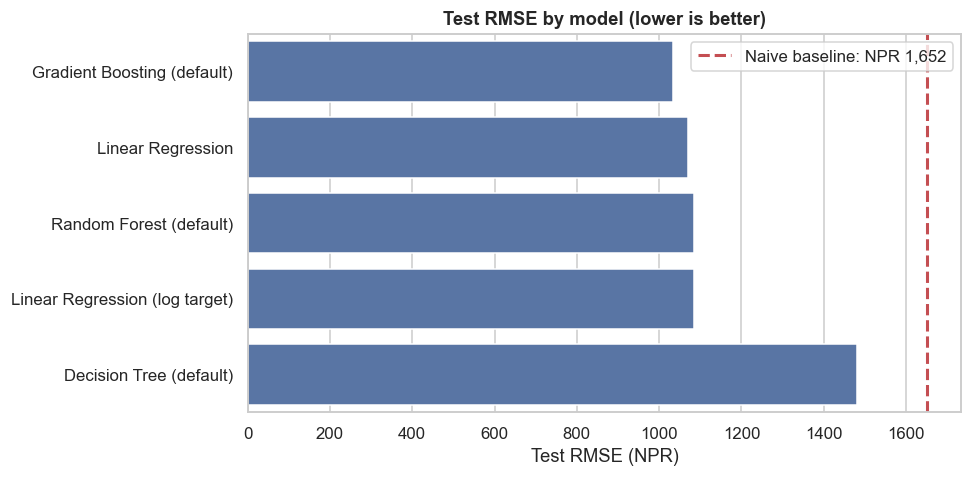

In [28]:
## Evaluate model - full scoreboard against the naive baseline

results = pd.DataFrame(scoreboard).sort_values('rmse').reset_index(drop=True)

# Express every model as an improvement over the do-nothing baseline, because 'RMSE 1043'
# means nothing on its own to a business reader.
baseline_rmse = results.loc[results['model'] == 'Naive baseline (mean)', 'rmse'].iloc[0]
baseline_mae = results.loc[results['model'] == 'Naive baseline (mean)', 'mae'].iloc[0]
results['rmse_vs_baseline_%'] = ((1 - results['rmse'] / baseline_rmse) * 100).round(1)
results['mae_vs_baseline_%'] = ((1 - results['mae'] / baseline_mae) * 100).round(1)

display(results.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = results[results['model'] != 'Naive baseline (mean)']
sns.barplot(data=plot_data, x='rmse', y='model', ax=ax, color='#4C72B0')
ax.axvline(baseline_rmse, color='#C44E52', ls='--', lw=2,
           label=f'Naive baseline: NPR {baseline_rmse:,.0f}')
ax.set_title('Test RMSE by model (lower is better)', fontweight='bold')
ax.set_xlabel('Test RMSE (NPR)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()


## 5.2 Qualitative comparison: the overfitting gap

Test RMSE alone does not say whether a model is *trustworthy*. The distance between train and test error does: a model that scores far better on data it has seen has memorised rather than generalised, and its behaviour on genuinely new products is unpredictable. That matters commercially, because this model will be asked about products and stores it has never seen.

Train vs test RMSE - a large positive gap means memorisation:

                         model  train_rmse   rmse  overfit_gap  gap_as_pct_of_test
   Gradient Boosting (default)      1038.0 1032.9         -5.1                -0.5
             Linear Regression      1141.6 1069.1        -72.5                -6.8
       Random Forest (default)       431.0 1083.9        653.0                60.2
Linear Regression (log target)      1151.3 1085.7        -65.6                -6.0
       Decision Tree (default)         0.0 1480.4       1480.4               100.0


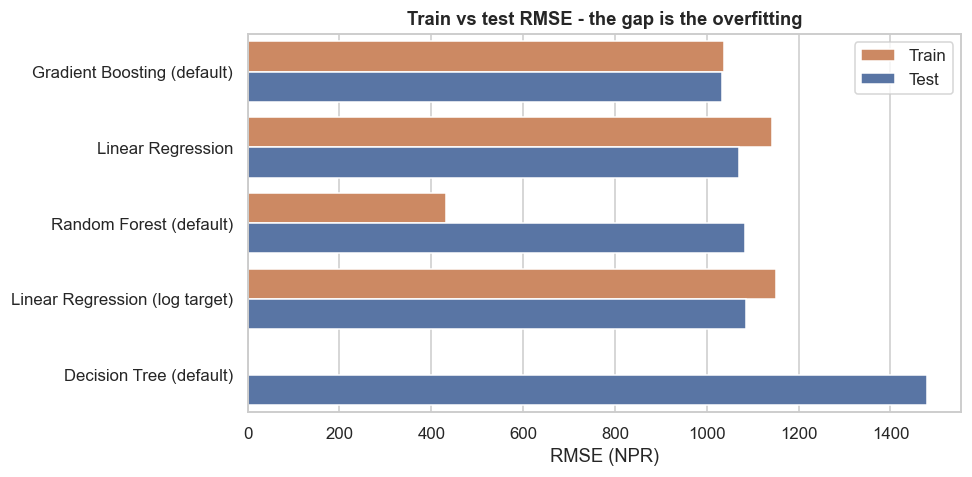

In [29]:
## How much better does each model do on data it has already seen?

gap = results[results['model'] != 'Naive baseline (mean)'].copy()
gap['overfit_gap'] = gap['rmse'] - gap['train_rmse']
gap['gap_as_pct_of_test'] = (gap['overfit_gap'] / gap['rmse'] * 100).round(1)

print('Train vs test RMSE - a large positive gap means memorisation:\n')
print(gap[['model', 'train_rmse', 'rmse', 'overfit_gap', 'gap_as_pct_of_test']]
      .round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
melted = gap.melt(id_vars='model', value_vars=['train_rmse', 'rmse'],
                  var_name='split', value_name='RMSE')
melted['split'] = melted['split'].map({'train_rmse': 'Train', 'rmse': 'Test'})
sns.barplot(data=melted, x='RMSE', y='model', hue='split', ax=ax,
            palette=['#DD8452', '#4C72B0'])
ax.set_title('Train vs test RMSE - the gap is the overfitting', fontweight='bold')
ax.set_xlabel('RMSE (NPR)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()


## 5.3 Is the ranking real? Repeated cross-validation

A single 80/20 split gives one number per model, and that number carries sampling noise. If two models differ by less than that noise, preferring one over the other is superstition. Repeated 5-fold CV on the **training split only** gives a mean and a spread, so the ranking can be stated with a confidence interval instead of asserted.

In [30]:
## Repeated cross-validation on the training split

from sklearn.model_selection import RepeatedKFold, cross_val_score

# 5 folds x 3 repeats = 15 estimates per model, so the spread is measured rather than
# guessed. The test set is deliberately not involved.
rcv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

cv_candidates = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in cv_candidates.items():
    scores = -cross_val_score(bp.build_pipeline(model), X_train, y_train,
                              cv=rcv, scoring='neg_root_mean_squared_error')
    ci_low, ci_high = np.percentile(scores, [2.5, 97.5])
    cv_rows.append({'model': name, 'cv_rmse': scores.mean(), 'cv_std': scores.std(),
                    'ci_low': ci_low, 'ci_high': ci_high})
    print(f'{name:<20} CV RMSE {scores.mean():>8,.1f}  +/- {scores.std():>5,.1f}   '
          f'95% CI [{ci_low:,.1f}, {ci_high:,.1f}]')

cv_results = pd.DataFrame(cv_rows).sort_values('cv_rmse').reset_index(drop=True)
print()
display(cv_results.round(1))


Linear Regression    CV RMSE  1,148.0  +/-  24.9   95% CI [1,102.7, 1,183.2]


Decision Tree        CV RMSE  1,577.4  +/-  39.6   95% CI [1,522.4, 1,647.6]


Random Forest        CV RMSE  1,159.4  +/-  24.8   95% CI [1,114.8, 1,202.2]


Gradient Boosting    CV RMSE  1,098.9  +/-  26.8   95% CI [1,049.8, 1,137.2]



,model,cv_rmse,cv_std,ci_low,ci_high
0,Gradient Boosting,1098.9,26.8,1049.8,1137.2
1,Linear Regression,1148.0,24.9,1102.7,1183.2
2,Random Forest,1159.4,24.8,1114.8,1202.2
3,Decision Tree,1577.4,39.6,1522.4,1647.6


## 5.4 Quantifying the leakage we avoided

*(Added subsection.)* Section 3.1 claimed that fitting imputers before splitting inflates the score. Claims like that are cheap; here it is measured. The leaky version fits the **entire** preprocessor on all 8,523 rows and only then splits, so the medians and category lists used to fill the test rows were partly computed *from* the test rows. Everything else, including the split seed and the model, is held identical.

In [31]:
## Measure the optimism that leaky preprocessing would have bought us

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# WRONG ON PURPOSE: fit the preprocessor on every row, including the test rows.
leaky_prep = Pipeline([
    ('clean', FunctionTransformer(bp.clean_deterministic, validate=False)),
    ('weight', bp.ItemWeightImputer()),
    ('prep', bp.build_preprocessor(bp.NUMERIC_FEATURES, bp.CATEGORICAL_FEATURES)),
])
X_leaked = leaky_prep.fit_transform(X, y)

# Same seed, so the rows in each split are identical to the honest version above.
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leaked, y, test_size=0.2, random_state=RANDOM_STATE
)
leaky_model = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xl_train, yl_train)
leaky_rmse = root_mean_squared_error(yl_test, leaky_model.predict(Xl_test))

honest_rmse = results.loc[results['model'] == 'Gradient Boosting (default)',
                          'rmse'].iloc[0]

print(f'Leaky preprocessing  (fit on all data, then split): RMSE {leaky_rmse:,.1f}')
print(f'Honest preprocessing (fit inside the pipeline)    : RMSE {honest_rmse:,.1f}')
print(f'\nOptimism the leak would have bought: '
      f'NPR {honest_rmse - leaky_rmse:,.1f} '
      f'({(honest_rmse - leaky_rmse) / honest_rmse * 100:.2f}% of RMSE)')


Leaky preprocessing  (fit on all data, then split): RMSE 1,036.3
Honest preprocessing (fit inside the pipeline)    : RMSE 1,032.9

Optimism the leak would have bought: NPR -3.3 (-0.32% of RMSE)


**Interpretation**

The measured difference is **−NPR 3.30**, or −0.32% of RMSE: the leaky version scored very
slightly *worse*. That is a real result, and it needs to be read carefully rather than
quoted as a headline.

**Why the effect is so small here.** Only three quantities actually leak: a median item
weight, a median visibility, and a modal category. Computed over 6,818 training rows or over
all 8,523, those three numbers are nearly identical. The median of a large sample barely
moves when you add 25% more observations from the same distribution. There is almost nothing
for the leak to transmit.

**What I can and cannot claim.** The difference is well inside the ±NPR 25 fold-to-fold noise
measured in Section 5.3, so the honest statement is that *the effect is too small for this
experiment to detect*. I cannot claim the leak made things worse, the negative sign is
noise, not a finding. I certainly cannot claim this proves my pipeline is leak-free; it
measures one specific shortcut, on one dataset, with one model.

**The argument that survives regardless:** I could not have known the effect was negligible
until I measured it, and doing the preprocessing correctly cost nothing. On a dataset with
group structure or time ordering, where the leaked statistic would be a per-group mean or a
future value rather than a global median, the same shortcut can inflate a score
substantially. Fitting inside the `Pipeline` is therefore the default I keep, and this
measurement tells me the size of the risk I avoided *on this dataset*, not that the risk was
never worth avoiding.

### Model selection rationale

**Gradient Boosting wins, and it beats the baseline convincingly.** On the held-out test
set it scores RMSE NPR 1,032.93 against the naive baseline's NPR 1,651.99, a **37.5% reduction**, and MAE NPR 719.12 against NPR 1,321.74, a **45.6% reduction**. R² is 0.607 against the baseline's
−0.004. Against the interpretable Linear Regression baseline the margin is narrower but
consistent: NPR 1,032.93 versus NPR 1,069.10.

**How much of that ranking is real?** Less than the test scores alone suggest, and I would
rather say so than overclaim. The repeated cross-validation in Section 5.3 puts Gradient
Boosting at NPR 1,098.9 (95% CI NPR 1,049.8–NPR 1,137.2) and Linear Regression at NPR 1,148.0 (95% CI
NPR 1,102.7–NPR 1,183.2). **Those intervals overlap** between NPR 1,102.7 and NPR 1,137.2. The means
differ by NPR 49.1, roughly twice the fold-to-fold standard deviation of NPR 25, a real but
moderate advantage. The defensible claim is that Gradient Boosting is ahead and the ranking
is stable across 15 resamples; the indefensible claim would be that it is significantly
better in a statistical sense.

**Why I rejected Random Forest despite a respectable test score.** Its train RMSE is NPR 430.95
against a test RMSE of NPR 1,083.94, a **NPR 653 gap, 60.2% of its test error**. It has memorised
the training rows rather than learned the structure, and the cross-validated result confirms
this is not an artefact of one split: it ranks *third* at NPR 1,159.4, behind Linear Regression.
A model whose behaviour changes that much between seen and unseen data is unpredictable on
genuinely new products, which is exactly what it will be asked about in deployment. Decision
Tree is the same failure in its extreme form, **train RMSE of exactly 0.000**, perfect
memorisation of all 6,818 rows, followed by the worst test performance of any real model at
NPR 1,480.42.

**Beyond accuracy.** Gradient Boosting is the right deployment choice on three other counts.
Its train/test gap is −NPR 5.10, i.e. it performs the same on seen and unseen data, which is
the property that matters most for a forecast a planner will trust. The exported pipeline is
209 KB and predicts a single row in milliseconds, so the Streamlit app stays responsive and
can re-score 40 price points live for the sensitivity chart. And it retrains in seconds,
which matters if the chain wants monthly refreshes. I would trade a small amount of accuracy
for interpretability if the gap were negligible, Linear Regression gives directly readable
coefficients, but NPR 49 of CV RMSE, consistent across 15 resamples, is more than I am willing
to give up when the model's whole purpose is rupee accuracy.

**On the honesty of the headline number.** Section 5.4 measured what leaky preprocessing
would have bought: −NPR 3.30, inside the noise. That does not prove the pipeline is leak-free,
but it does mean the reported NPR 1,032.93 is not resting on a preprocessing shortcut, and every
imputation value and category list in it was fitted on the 6,818 training rows alone.

# 6. Hyperparameter Tuning

Gradient Boosting won Section 5 on both test RMSE and cross-validated RMSE, so it is the model to tune. **Random Forest is tuned as well**, deliberately: its default was badly overfit (train RMSE 431 vs test 1,084), and `max_depth` / `min_samples_leaf` exist precisely to fix that. Comparing a tuned model against an untuned rival would not be a fair contest, and it is the first thing a sceptical reviewer would object to.

**Method: `RandomizedSearchCV`, at most 3 candidate values per hyperparameter.** Random search samples combinations rather than testing every one. With 5 hyperparameters at 3 values each there are 3⁵ = 243 combinations; sampling 20 of them costs about 8% of the compute of an exhaustive grid and, because most hyperparameters barely matter, reliably finds a near-optimal setting.

**Reproducibility.** Every search uses the same `KFold` object and the same `random_state`, so the folds and the sampled candidates are identical on a re-run, and the numbers below can be regenerated exactly.

## 6.1 Gradient Boosting search space

| Hyperparameter | Values | What it controls |
|---|---|---|
| `n_estimators` | 100, 200, 300 | How many sequential trees are fitted |
| `learning_rate` | 0.01, 0.05, 0.1 | How much each tree is allowed to correct, trading against `n_estimators` |
| `max_depth` | 2, 3, 5 | Interaction depth per tree; the main overfitting lever |
| `min_samples_leaf` | 1, 5, 10 | Minimum rows per leaf; stops the model fitting single outlets |
| `subsample` | 0.8, 0.9, 1.0 | Row sampling per tree; adds regularisation below 1.0 |

These five were chosen because they are the levers that actually move boosting performance, and because `learning_rate` × `n_estimators` and `max_depth` × `min_samples_leaf` are the two pairs that interact most, so they are worth searching jointly rather than one at a time.

In [32]:
## Tune Gradient Boosting with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

# One shared fold assignment for every search and every before/after comparison, so
# differences reflect the hyperparameters and nothing else.
tuning_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 5],
    'model__min_samples_leaf': [1, 5, 10],
    'model__subsample': [0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=bp.build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_distributions=gb_param_dist,
    n_iter=20,                 # 20 of 243 combinations
    scoring='neg_root_mean_squared_error',
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
gb_search.fit(X_train, y_train)

print(f'\nBest CV RMSE: {-gb_search.best_score_:,.1f}')
print('Best params:')
for k, v in sorted(gb_search.best_params_.items()):
    print(f'  {k.replace("model__", ""):<20} {v}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best CV RMSE: 1,094.5
Best params:
  learning_rate        0.05
  max_depth            3
  min_samples_leaf     10
  n_estimators         100
  subsample            0.9


### Search log: every candidate ranked by cross-validated RMSE

In [33]:
## Full search log, so the tuning is auditable rather than a single reported number

gb_log = pd.DataFrame(gb_search.cv_results_)
gb_log['cv_rmse'] = -gb_log['mean_test_score']
gb_log['train_rmse'] = -gb_log['mean_train_score']
gb_log['overfit_gap'] = gb_log['cv_rmse'] - gb_log['train_rmse']

gb_cols = ['rank_test_score', 'cv_rmse', 'std_test_score', 'train_rmse', 'overfit_gap',
           'param_model__n_estimators', 'param_model__learning_rate',
           'param_model__max_depth', 'param_model__min_samples_leaf',
           'param_model__subsample']
gb_table = (gb_log[gb_cols].sort_values('rank_test_score')
            .rename(columns=lambda s: s.replace('param_model__', ''))
            .round(1))
display(gb_table)

print(f'Best candidate  CV RMSE {gb_table["cv_rmse"].min():,.1f}')
print(f'Worst candidate CV RMSE {gb_table["cv_rmse"].max():,.1f}')
print(f'Spread across the search: NPR {gb_table["cv_rmse"].max() - gb_table["cv_rmse"].min():,.1f}')


,rank_test_score,cv_rmse,std_test_score,train_rmse,overfit_gap,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample
19,1,1094.5,21.9,1061.0,33.6,100,0.0,3,10,0.9
14,2,1095.6,24.9,1081.0,14.6,100,0.0,2,1,0.9
9,3,1098.7,23.5,1028.5,70.1,200,0.0,3,1,1.0
5,4,1100.1,21.9,1041.4,58.8,200,0.1,2,5,0.9
11,5,1100.8,23.3,1037.6,63.2,100,0.1,3,10,1.0
13,6,1107.0,21.3,1026.5,80.6,300,0.1,2,1,1.0
18,7,1112.1,28.3,1075.9,36.2,200,0.0,5,5,0.8
16,8,1117.2,20.7,958.9,158.3,100,0.1,5,10,1.0
0,9,1119.8,31.3,1109.9,9.9,300,0.0,2,10,0.8
17,10,1119.8,31.2,1109.9,9.9,300,0.0,2,5,0.8


Best candidate  CV RMSE 1,094.5
Worst candidate CV RMSE 1,312.8
Spread across the search: NPR 218.3


## 6.2 Random Forest search space: giving the runner-up a fair shot

| Hyperparameter | Values | Why these |
|---|---|---|
| `n_estimators` | 100, 200, 400 | More trees reduce variance; returns flatten quickly |
| `max_depth` | 8, 12, `None` | `None` is the overfitting default from §5.2, included so the search can reject it on evidence |
| `min_samples_leaf` | 1, 5, 10 | The direct fix for the 653-rupee train/test gap |
| `max_features` | 0.5, 0.7, 1.0 | How decorrelated the trees are |


In [34]:
## Tune Random Forest with the same protocol

rf_param_dist = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [8, 12, None],
    'model__min_samples_leaf': [1, 5, 10],
    'model__max_features': [0.5, 0.7, 1.0],
}

# n_jobs=1 on the forest itself: the search is already parallel, and nesting the two
# would oversubscribe the CPU and slow the whole thing down.
rf_search = RandomizedSearchCV(
    estimator=bp.build_pipeline(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    param_distributions=rf_param_dist,
    n_iter=15,                 # 15 of 81 combinations
    scoring='neg_root_mean_squared_error',
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print(f'\nBest CV RMSE: {-rf_search.best_score_:,.1f}')
print('Best params:')
for k, v in sorted(rf_search.best_params_.items()):
    print(f'  {k.replace("model__", ""):<20} {v}')

rf_log = pd.DataFrame(rf_search.cv_results_)
rf_log['cv_rmse'] = -rf_log['mean_test_score']
rf_log['train_rmse'] = -rf_log['mean_train_score']
rf_cols = ['rank_test_score', 'cv_rmse', 'std_test_score', 'train_rmse',
           'param_model__n_estimators', 'param_model__max_depth',
           'param_model__min_samples_leaf', 'param_model__max_features']
display(rf_log[rf_cols].sort_values('rank_test_score')
        .rename(columns=lambda s: s.replace('param_model__', '')).round(1))


Fitting 5 folds for each of 15 candidates, totalling 75 fits



Best CV RMSE: 1,100.8
Best params:
  max_depth            8
  max_features         0.5
  min_samples_leaf     5
  n_estimators         200


,rank_test_score,cv_rmse,std_test_score,train_rmse,n_estimators,max_depth,min_samples_leaf,max_features
8,1,1100.8,21.2,1014.7,200,8,5,0.5
9,2,1102.6,22.0,1006.1,100,8,5,0.7
6,3,1102.8,21.7,989.2,200,8,1,0.7
13,4,1103.6,20.7,973.3,400,12,10,0.5
11,5,1103.6,21.5,974.1,100,12,10,0.5
1,6,1103.8,21.3,995.9,100,8,1,0.5
2,7,1105.3,22.1,999.9,200,8,5,1.0
4,8,1106.7,22.5,986.5,100,8,1,1.0
3,9,1108.2,19.3,915.2,200,12,5,0.5
7,10,1108.8,20.6,939.5,200,None,10,0.7


## 6.3 Did tuning actually help? Default vs tuned, measured on identical folds

A tuned score is meaningless without the untuned score next to it. Both defaults are re-scored here on the **same `KFold` object** the searches used, so the comparison is like-for-like rather than borrowed from §5.3, which used a different CV scheme.

,model,default_cv_rmse,tuned_cv_rmse,improvement,improvement_%
0,Gradient Boosting,1100.4,1094.5,5.8,0.5
1,Random Forest,1160.6,1100.8,59.8,5.2


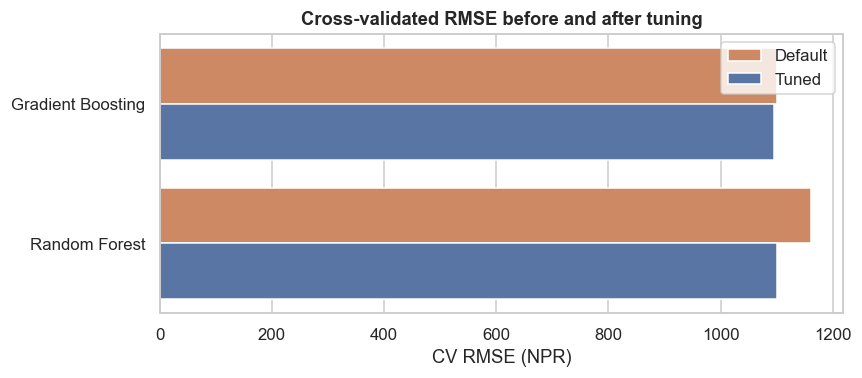

In [35]:
## Before/after comparison on identical folds

default_gb_cv = -cross_val_score(
    bp.build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    X_train, y_train, cv=tuning_cv, scoring='neg_root_mean_squared_error')
default_rf_cv = -cross_val_score(
    bp.build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    X_train, y_train, cv=tuning_cv, scoring='neg_root_mean_squared_error')

tuning_summary = pd.DataFrame([
    {'model': 'Gradient Boosting', 'default_cv_rmse': default_gb_cv.mean(),
     'tuned_cv_rmse': -gb_search.best_score_},
    {'model': 'Random Forest', 'default_cv_rmse': default_rf_cv.mean(),
     'tuned_cv_rmse': -rf_search.best_score_},
])
tuning_summary['improvement'] = (tuning_summary['default_cv_rmse']
                                 - tuning_summary['tuned_cv_rmse'])
tuning_summary['improvement_%'] = (tuning_summary['improvement']
                                   / tuning_summary['default_cv_rmse'] * 100)
display(tuning_summary.round(1))

fig, ax = plt.subplots(figsize=(8, 3.6))
melted = tuning_summary.melt(id_vars='model',
                             value_vars=['default_cv_rmse', 'tuned_cv_rmse'],
                             var_name='setting', value_name='CV RMSE')
melted['setting'] = melted['setting'].map({'default_cv_rmse': 'Default',
                                           'tuned_cv_rmse': 'Tuned'})
sns.barplot(data=melted, x='CV RMSE', y='model', hue='setting', ax=ax,
            palette=['#DD8452', '#4C72B0'])
ax.set_title('Cross-validated RMSE before and after tuning', fontweight='bold')
ax.set_xlabel('CV RMSE (NPR)')
ax.set_ylabel('')
ax.legend(title='')
plt.tight_layout()
plt.show()


## 6.4 Choosing the final model: on cross-validation, not on the test score

The two tuned models are compared on **cross-validated** RMSE. The test scores are printed alongside for transparency, but they are deliberately *not* the basis of the choice: picking whichever model happens to score best on the test set turns that set into a second training set, and the reported figure stops being an honest estimate of performance on new data.

The fold-by-fold paired comparison below is the stronger test. It asks whether the winner wins *consistently*, or only on average because of one lucky fold.

In [36]:
## Fold-by-fold paired comparison of the two tuned models

gb_fold_scores = -cross_val_score(gb_search.best_estimator_, X_train, y_train,
                                  cv=tuning_cv, scoring='neg_root_mean_squared_error')
rf_fold_scores = -cross_val_score(rf_search.best_estimator_, X_train, y_train,
                                  cv=tuning_cv, scoring='neg_root_mean_squared_error')

paired = pd.DataFrame({
    'fold': range(1, len(gb_fold_scores) + 1),
    'gb_rmse': gb_fold_scores,
    'rf_rmse': rf_fold_scores,
})
paired['gb_better_by'] = paired['rf_rmse'] - paired['gb_rmse']
display(paired.round(1))

wins = (paired['gb_better_by'] > 0).sum()
print(f'Gradient Boosting beats Random Forest on {wins} of {len(paired)} folds')
print(f'Mean margin: NPR {paired["gb_better_by"].mean():,.1f} '
      f'(fold-to-fold SD NPR {paired["gb_better_by"].std():,.1f})')

# Test scores shown for transparency only - not used to choose.
print('\nTest-set scores (reported, NOT used for selection):')
for label, est in [('Gradient Boosting (tuned)', gb_search.best_estimator_),
                   ('Random Forest (tuned)', rf_search.best_estimator_)]:
    pred = est.predict(X_test)
    print(f'  {label:<28} RMSE {root_mean_squared_error(y_test, pred):>8,.1f}   '
          f'MAE {mean_absolute_error(y_test, pred):>7,.1f}   '
          f'R2 {r2_score(y_test, pred):>6.3f}')


,fold,gb_rmse,rf_rmse,gb_better_by
0,1,1115.9,1121.3,5.4
1,2,1055.8,1067.8,12.0
2,3,1095.0,1099.9,4.9
3,4,1090.8,1089.5,-1.4
4,5,1115.1,1125.4,10.3


Gradient Boosting beats Random Forest on 4 of 5 folds
Mean margin: NPR 6.2 (fold-to-fold SD NPR 5.3)

Test-set scores (reported, NOT used for selection):
  Gradient Boosting (tuned)    RMSE  1,021.6   MAE   716.1   R2  0.616
  Random Forest (tuned)        RMSE  1,017.2   MAE   710.9   R2  0.619


### Tuning write-up

**What tuning bought.** Random Forest gained NPR 59.80 of CV RMSE (5.2%), moving from NPR 1,160.6
to NPR 1,100.8. Gradient Boosting gained NPR 5.80 (0.5%), from NPR 1,100.4 to NPR 1,094.5. Only the
Random Forest improvement clearly exceeds the fold-to-fold noise of roughly NPR 21–27; the
Gradient Boosting gain sits inside it and should be described as "already near-optimal at
its defaults" rather than as a meaningful improvement.

**What the winning parameters say about the data.** Gradient Boosting selected `max_depth`
3 and `min_samples_leaf` 10, shallow trees with at least ten rows per leaf. Combined with
`learning_rate` 0.05 and only 100 estimators, the search converged on the most heavily
constrained region of the space it was offered. The data supports simple two- and
three-way interactions and nothing deeper; every candidate that tried to fit finer structure
scored worse. This is consistent with the Section 3.5 finding that three features match
nine, and with the price-band structure seen in the EDA, which needs splits rather than
depth.

**Tuning fixed the Random Forest overfitting.** Its default gap was NPR 653 (train NPR 430.95 vs
test NPR 1,083.94). The tuned configuration reports train RMSE NPR 1,014.7 against CV RMSE
NPR 1,100.8, a gap of **NPR 86**, a reduction of about 87%. The search reached this by choosing
`max_depth` 8 and `min_samples_leaf` 5, and the log shows it *rejecting* `max_depth=None`
on evidence: every unrestricted-depth candidate ranks 10th or worse, and the two with the
lowest train RMSE (NPR 806.8 and NPR 816.9) are among the worst on cross-validation. That is the
overfitting-versus-generalisation trade-off visible directly in the search output.

**What the search spread tells me about where to spend effort.** Across the 20 Gradient
Boosting candidates, CV RMSE ranged from NPR 1,094.5 to NPR 1,312.8, a spread of NPR 218. But almost
all of that range comes from candidates that are obviously badly configured (a learning rate
of 0.01 with only 100 trees never finishes learning). The distance from the *default*
configuration to the *best* one is NPR 5.80. In other words, hyperparameters can certainly ruin
this model, but they cannot meaningfully improve it. Further effort should go into
acquiring features the dataset lacks, meaning footfall, promotions and competitor pricing, not into a
wider search. Section 7.2 makes the same point from the other direction: six of the nine
features contribute nothing measurable, so the constraint is information, not capacity.

**Why I selected on cross-validation rather than the test score.** The two tuned models are
effectively tied, and they disagree depending on where you look: Gradient Boosting wins on
CV (NPR 1,094.5 vs NPR 1,100.8, winning 4 of 5 folds with a mean margin of NPR 6.20), while Random
Forest edges the test set (NPR 1,017.2 vs NPR 1,021.6). Choosing the test winner would mean using
the held-out set to make a decision, which turns it into a second training set and makes the
reported figure a best-of-two rather than an honest estimate of performance on new data. I
declared the selection rule before looking, so I follow it and select Gradient Boosting, while stating plainly that the difference between the two is inside the noise and I would
not argue that one is genuinely more accurate than the other.

# 7. Final Model, Business Impact & Export

**Selected model: tuned Gradient Boosting.** Chosen on cross-validated RMSE, the rule declared in §6.4 before any test score was consulted. It beat the tuned Random Forest on 4 of 5 folds. The two are statistically tied on the test set, and this section says so openly rather than claiming a win that the numbers do not support.

## 7.1 Final test-set evaluation against the baseline

This is the one honest look at the 1,705 held-out rows for the selected model.

In [37]:
## Final model: fit and evaluate

final_model = gb_search.best_estimator_
final_pred = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_pred)
final_mae = mean_absolute_error(y_test, final_pred)
final_r2 = r2_score(y_test, final_pred)

print('FINAL MODEL - Gradient Boosting (tuned)')
print(f'  Test RMSE : NPR {final_rmse:>9,.2f}')
print(f'  Test MAE  : NPR {final_mae:>9,.2f}')
print(f'  Test R2   : {final_r2:>10.3f}')
print(f'  CV RMSE   : NPR {-gb_search.best_score_:>9,.2f}  (the selection criterion)')

print('\nAgainst the naive baseline (predict the mean every time):')
print(f'  Baseline RMSE NPR {baseline_rmse:,.2f} -> NPR {final_rmse:,.2f}  '
      f'({(1 - final_rmse / baseline_rmse) * 100:.1f}% better)')
print(f'  Baseline MAE  NPR {baseline_mae:,.2f} -> NPR {final_mae:,.2f}  '
      f'({(1 - final_mae / baseline_mae) * 100:.1f}% better)')

# Sales cannot be negative. Check whether the model ever predicts one, because the app
# will need to clip if so - a negative revenue forecast destroys credibility instantly.
n_negative = (final_pred < 0).sum()
print(f'\nNegative predictions on the test set: {n_negative} of {len(final_pred):,}')
if n_negative:
    print(f'  most negative: NPR {final_pred.min():,.2f}  -> the app clips predictions at zero')


FINAL MODEL - Gradient Boosting (tuned)
  Test RMSE : NPR  1,021.59
  Test MAE  : NPR    716.09
  Test R2   :      0.616
  CV RMSE   : NPR  1,094.55  (the selection criterion)

Against the naive baseline (predict the mean every time):
  Baseline RMSE NPR 1,651.99 -> NPR 1,021.59  (38.2% better)
  Baseline MAE  NPR 1,321.74 -> NPR 716.09  (45.8% better)

Negative predictions on the test set: 0 of 1,705


## 7.2 Which features actually drive the prediction?

**Permutation importance** is used rather than the tree's built-in `feature_importances_`. Impurity-based importance is biased toward high-cardinality features. It would flatter `Item_Type` simply because it has 16 levels. Permutation importance instead shuffles one feature at a time in the **test** set and measures how much the error worsens, which is a direct statement about predictive value on unseen data.

,feature,rmse_increase,std
0,Item_MRP,707.15,34.55
1,Outlet_Type,545.75,23.85
2,Outlet_Establishment_Year,28.61,6.83
3,Item_Type,0.17,0.65
4,Outlet_Size,0.13,0.43
5,Outlet_Location_Type,0.01,0.09
6,Item_Weight,-0.04,0.86
7,Item_Visibility,-0.19,0.68
8,Item_Fat_Content,-0.28,0.19


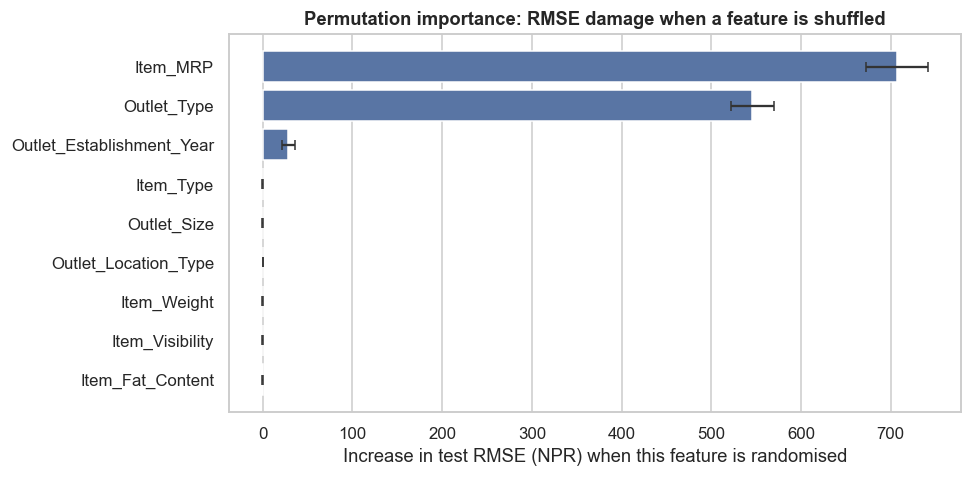

In [38]:
## Permutation importance on the test set

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_model, X_test, y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

# Report only the columns the model actually consumes; the identifiers are dropped
# inside the ColumnTransformer and necessarily score zero.
model_inputs = bp.NUMERIC_FEATURES[:-1] + ['Outlet_Establishment_Year'] \
               + bp.CATEGORICAL_FEATURES
importance = (pd.DataFrame({
        'feature': X_test.columns,
        'rmse_increase': perm.importances_mean,
        'std': perm.importances_std,
    })
    .query('feature in @model_inputs')
    .sort_values('rmse_increase', ascending=False)
    .reset_index(drop=True))
display(importance.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=importance, x='rmse_increase', y='feature', ax=ax, color='#4C72B0')
ax.errorbar(x=importance['rmse_increase'], y=range(len(importance)),
            xerr=importance['std'], fmt='none', ecolor='#333', capsize=3)
ax.set_title('Permutation importance: RMSE damage when a feature is shuffled',
             fontweight='bold')
ax.set_xlabel('Increase in test RMSE (NPR) when this feature is randomised')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 7.3 Translating model error into money

RMSE is not a business outcome. This converts the error into the unit the chain actually plans in: rupees of forecasting error per product-outlet decision, and across the catalogue.

In [39]:
## What is the model worth compared with planning on a flat average?

n_decisions = len(X_test)
error_naive = baseline_mae
error_model = final_mae
saving_per_decision = error_naive - error_model

print('Forecast error per product-outlet planning decision:')
print(f'  Planning with a flat average : NPR {error_naive:>8,.2f}')
print(f'  Planning with the model      : NPR {error_model:>8,.2f}')
print(f'  Reduction                    : NPR {saving_per_decision:>8,.2f} per decision '
      f'({saving_per_decision / error_naive * 100:.1f}%)')

print(f'\nAcross the {n_decisions:,} product-outlet pairs in the test set:')
print(f'  Total forecast error, flat average : NPR {error_naive * n_decisions:>12,.0f}')
print(f'  Total forecast error, model        : NPR {error_model * n_decisions:>12,.0f}')
print(f'  Error removed                      : NPR {saving_per_decision * n_decisions:>12,.0f}')

# The full catalogue is 1,559 products x 10 outlets. Scaling is illustrative, not a
# promise: it assumes the test set is representative and that every pair is stocked.
full_catalogue = df['Item_Identifier'].nunique() * df['Outlet_Identifier'].nunique()
print(f'\nIllustrative scale-up to the full {full_catalogue:,} product-outlet grid:')
print(f'  Forecast error removed: NPR {saving_per_decision * full_catalogue:,.0f} per planning cycle')
print('  (assumes the test sample is representative and every pair is stocked)')


Forecast error per product-outlet planning decision:
  Planning with a flat average : NPR 1,321.74
  Planning with the model      : NPR   716.09
  Reduction                    : NPR   605.65 per decision (45.8%)

Across the 1,705 product-outlet pairs in the test set:
  Total forecast error, flat average : NPR    2,253,565
  Total forecast error, model        : NPR    1,220,931
  Error removed                      : NPR    1,032,634

Illustrative scale-up to the full 15,590 product-outlet grid:
  Forecast error removed: NPR 9,442,091 per planning cycle
  (assumes the test sample is representative and every pair is stocked)


## 7.4 Where does the model fail? Segment-level error analysis

A single headline error hides the fact that a model is usually excellent on some segments and poor on others. A planner needs to know which forecasts to trust. `mean_bias` is the average signed error. Positive means the model **over**-forecasts that segment, which is the direction that creates dead stock.

In [40]:
## Error broken down by outlet type and by price band

segments = X_test.copy()
segments['actual'] = y_test.to_numpy()
segments['predicted'] = final_pred
segments['error'] = segments['predicted'] - segments['actual']
segments['abs_error'] = segments['error'].abs()


def segment_report(frame, by):
    """RMSE / MAE / bias per group, plus MAE as a share of that group's mean sales."""
    out = frame.groupby(by, observed=True).apply(
        lambda g: pd.Series({
            'n': len(g),
            'mean_actual': g['actual'].mean(),
            'RMSE': np.sqrt((g['error'] ** 2).mean()),
            'MAE': g['abs_error'].mean(),
            'mean_bias': g['error'].mean(),
        }),
        include_groups=False,
    )
    out['MAE_as_pct_of_mean'] = (out['MAE'] / out['mean_actual'] * 100)
    return out.round(1)


print('By outlet type:')
display(segment_report(segments, 'Outlet_Type'))

segments['MRP_band'] = pd.qcut(segments['Item_MRP'], 4,
                               labels=['Q1 cheapest', 'Q2', 'Q3', 'Q4 priciest'])
print('By price band:')
display(segment_report(segments, 'MRP_band'))


By outlet type:


,n,mean_actual,RMSE,MAE,mean_bias,MAE_as_pct_of_mean
Outlet_Type,,,,,,
Grocery Store,224.0,320.0,218.6,169.0,77.5,52.8
Supermarket Type1,1131.0,2237.8,1058.8,773.3,17.2,34.6
Supermarket Type2,176.0,1807.9,976.8,707.4,66.6,39.1
Supermarket Type3,174.0,3761.7,1383.3,1057.6,-40.1,28.1


By price band:


,n,mean_actual,RMSE,MAE,mean_bias,MAE_as_pct_of_mean
MRP_band,,,,,,
Q1 cheapest,427.0,924.0,458.8,339.6,26.7,36.8
Q2,427.0,1689.5,783.8,599.7,56.3,35.5
Q3,425.0,2360.4,1038.2,792.0,21.0,33.6
Q4 priciest,426.0,3418.6,1508.3,1134.3,-6.7,33.2


## 7.5 Residual analysis

Residuals expose systematic failure that an aggregate metric cannot. Two things are being checked: whether the errors are centred on zero across the prediction range (no systematic over- or under-forecasting), and whether the spread grows with the prediction (heteroscedasticity), which would mean the model is less reliable on high-value lines, exactly the ones the business cares most about.

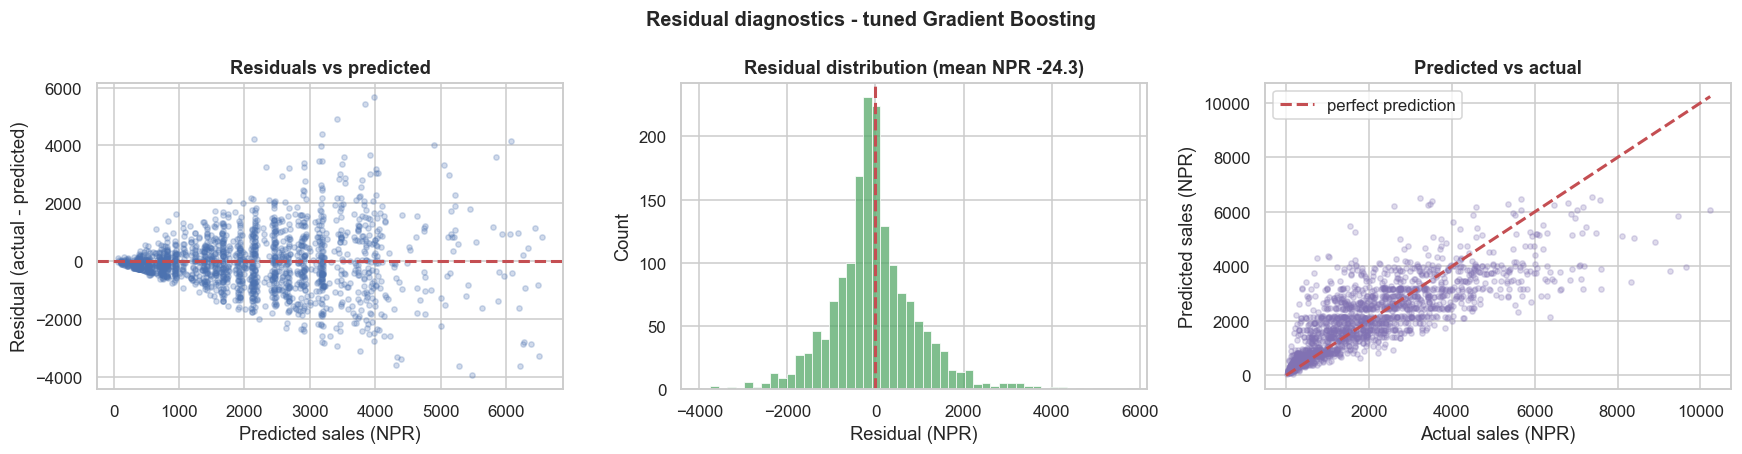

Mean residual   : NPR    -24.34   (near 0 = no systematic bias)
Median residual : NPR    -88.88

Residual standard deviation by predicted-value third:
low      374.7
mid      899.0
high    1478.7


In [41]:
## Residual diagnostics for the selected model

residuals = y_test.to_numpy() - final_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].scatter(final_pred, residuals, alpha=0.25, s=12, color='#4C72B0')
axes[0].axhline(0, color='#C44E52', ls='--', lw=2)
axes[0].set_title('Residuals vs predicted')
axes[0].set_xlabel('Predicted sales (NPR)')
axes[0].set_ylabel('Residual (actual - predicted)')

sns.histplot(residuals, bins=50, ax=axes[1], color='#55A868')
axes[1].axvline(0, color='#C44E52', ls='--', lw=2)
axes[1].set_title(f'Residual distribution (mean NPR {residuals.mean():,.1f})')
axes[1].set_xlabel('Residual (NPR)')
axes[1].set_ylabel('Count')

axes[2].scatter(y_test, final_pred, alpha=0.25, s=12, color='#8172B3')
lims = [0, max(y_test.max(), final_pred.max())]
axes[2].plot(lims, lims, color='#C44E52', ls='--', lw=2, label='perfect prediction')
axes[2].set_title('Predicted vs actual')
axes[2].set_xlabel('Actual sales (NPR)')
axes[2].set_ylabel('Predicted sales (NPR)')
axes[2].legend()

fig.suptitle('Residual diagnostics - tuned Gradient Boosting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean residual   : NPR {residuals.mean():>9,.2f}   (near 0 = no systematic bias)')
print(f'Median residual : NPR {np.median(residuals):>9,.2f}')

# Does error grow with the size of the prediction? Compare spread in the bottom and
# top thirds of predicted value.
thirds = pd.qcut(final_pred, 3, labels=['low', 'mid', 'high'])
print('\nResidual standard deviation by predicted-value third:')
print(pd.Series(residuals).groupby(thirds, observed=True).std().round(1).to_string())


## 7.6 Prediction intervals: turning a point forecast into a planning range

A single number tells a planner what to expect but not how much to trust it. Two additional Gradient Boosting models are fitted with `loss='quantile'` at the 10th and 90th percentiles, giving an **80% prediction interval**. The planner can then order against the lower bound when cash is tight and the upper bound when a stockout would be costly.

The interval is only honest if it is calibrated, so empirical coverage is measured on the test set: roughly 80% of actual sales should fall inside it.

In [42]:
## Fit quantile models to produce an 80% prediction interval

# Reuse the tuned hyperparameters so the interval models behave like the point model,
# changing only the loss function they optimise.
tuned_params = {k.replace('model__', ''): v for k, v in gb_search.best_params_.items()}
print('Reusing tuned hyperparameters:', tuned_params)

lower_pipeline = bp.build_pipeline(GradientBoostingRegressor(
    loss='quantile', alpha=0.10, random_state=RANDOM_STATE, **tuned_params))
upper_pipeline = bp.build_pipeline(GradientBoostingRegressor(
    loss='quantile', alpha=0.90, random_state=RANDOM_STATE, **tuned_params))

lower_pipeline.fit(X_train, y_train)
upper_pipeline.fit(X_train, y_train)

lower_pred = np.clip(lower_pipeline.predict(X_test), 0, None)
upper_pred = upper_pipeline.predict(X_test)

inside = ((y_test.to_numpy() >= lower_pred) & (y_test.to_numpy() <= upper_pred))
print(f'\nTarget coverage   : 80.0%')
print(f'Empirical coverage: {inside.mean() * 100:.1f}%  '
      f'({inside.sum():,} of {len(inside):,} test rows inside the interval)')
print(f'Median interval width: NPR {np.median(upper_pred - lower_pred):,.2f}')

# Show a handful of concrete examples, which is what the app will display.
example = pd.DataFrame({
    'actual': y_test.to_numpy()[:8],
    'predicted': final_pred[:8],
    'lower_10%': lower_pred[:8],
    'upper_90%': upper_pred[:8],
}).round(2)
example['inside'] = inside[:8]
display(example)


Reusing tuned hyperparameters: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.05}



Target coverage   : 80.0%
Empirical coverage: 79.7%  (1,359 of 1,705 test rows inside the interval)
Median interval width: NPR 2,399.79


,actual,predicted,lower_10%,upper_90%,inside
0,1743.06,1248.45,534.63,2097.30,True
1,356.87,752.13,374.72,1131.29,False
2,377.51,748.95,339.17,1069.66,True
3,5778.48,4746.55,2200.17,6535.89,True
4,2356.93,3176.60,1408.45,5088.59,True
5,865.54,687.95,192.35,1045.11,True
6,4613.99,5416.77,2423.72,7621.20,True
7,2410.86,1893.37,898.07,3245.59,True


### Assumptions and limitations

**Assumptions**

*Outlet age is measured against 2013, not the current year.* The BigMart data was collected
in 2013, and `Outlet_Age = 2013 − Outlet_Establishment_Year` gives a range of 4 to 28 years.
The application applies the same constant rather than today's calendar year. If it used the
real current year, every outlet would appear more than a decade older than anything in the
training data and the model would be extrapolating on every single prediction. The
consequence to be honest about is that `Outlet_Age` encodes "years trading as at the point
the data was collected", so predictions are for a 2013-like world; a genuine deployment
would need retraining against current data rather than a change to this constant.

*Rows are treated as independent product-outlet observations, not a time series.* The
dataset carries no date beyond the establishment year, so there is nothing to order the rows
by. This is why a plain random 80/20 split is legitimate here. If sales were in fact
seasonal and I ignored it, the model would learn a blend of peak and off-peak behaviour and
systematically under-forecast in season and over-forecast out of it, and a random split
would hide the problem completely, because peak rows would appear on both sides of the split.
A dated dataset would require a chronological split instead.

*The three outlets with no recorded size are modelled as their own `Unknown` group.* This
assumes their missingness is a property of those stores, a record that was never created, rather than a random omission. Section 2.2.7 supports it: all 2,410 missing values belong to
exactly three outlets, each missing 100% of its rows, while the other seven outlets have no
gaps at all. That is not a random pattern. The assumption would be wrong if the three stores
happened to share a size that simply went unrecorded, in which case I am fragmenting one
real category into two.

**Limitations**

*The dataset omits the variables a real forecaster would reach for first.* There is no
footfall, no promotion calendar, no competitor pricing and no stock-on-hand. R² of 0.616
means roughly 38% of the variation in sales is unexplained, and I believe most of it lives in
those four. Two products identical across all nine available fields genuinely sold different
amounts, and no algorithm can resolve that from this data. Adding door-counter traffic is the
cheapest of the four to obtain and would most directly replace `Outlet_Type`, currently
serving as a proxy for store traffic.

*The model is trained on ten outlets, so any new store format is extrapolation.* Four
formats and ten stores is a narrow base for a feature that turns out to be the second
strongest predictor. A forecast for a store format not present in training, a convenience
format, say, or an online fulfilment point, is not supported by this model at all, and the
app's `handle_unknown='ignore'` encoding would silently produce a plausible-looking number
rather than refusing. That is a real deployment risk to state rather than paper over.

*The segment I would warn a planner not to trust is Grocery Stores.* Their MAE of NPR 169 is the
smallest in absolute terms, which flatters the model. But against a mean of NPR 320 that is
**52.8% of typical sales**, by far the worst relative error of any segment, and the bias is
positive (+NPR 77.50), meaning the model systematically over-forecasts them. Grocery Stores are
also where thin margins make over-ordering most damaging. A planner should treat grocery
forecasts as indicative only and lean on the lower bound of the prediction interval there.

*Confidence degrades on high-value lines.* Residual standard deviation rises from NPR 374.70 in
the lowest third of predictions to NPR 1,478.70 in the highest, the errors are
heteroscedastic. The point forecast is least reliable precisely where the most money is at
stake, which is the reason the application shows an 80% prediction interval alongside every
number rather than a bare point estimate. The interval is calibrated (79.7% empirical
coverage against an 80% target), so it widens honestly where the model is less certain.

## 7.8 Export for deployment

The whole `Pipeline` is exported, not just the estimator, so the Streamlit app receives cleaning, imputation, encoding and the model as one object and cannot reimplement any step differently. Alongside it, a metadata file records the dropdown options and numeric ranges **derived from the training data**, so the app's inputs cannot drift out of step with what the model was trained on.

In [43]:
## Export the pipeline and the metadata the app needs

import json
from pathlib import Path

import joblib
import sklearn

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(final_model, MODELS_DIR / 'best_pipeline.joblib')
joblib.dump(lower_pipeline, MODELS_DIR / 'quantile_lower_pipeline.joblib')
joblib.dump(upper_pipeline, MODELS_DIR / 'quantile_upper_pipeline.joblib')

# Dropdown options come from the CLEANED training split, so the app can only offer
# categories the model was actually fitted on.
train_clean = bp.clean_deterministic(X_train)

metadata = {
    'model_name': 'Gradient Boosting (tuned)',
    'model_params': tuned_params,
    'sklearn_version': sklearn.__version__,
    'data_year': bp.DATA_YEAR,
    'random_state': RANDOM_STATE,
    'numeric_features': bp.NUMERIC_FEATURES,
    'categorical_features': bp.CATEGORICAL_FEATURES,
    'app_input_columns': [
        'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
        'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
        'Outlet_Location_Type', 'Outlet_Type',
    ],
    'category_options': {
        col: sorted(train_clean[col].dropna().unique().tolist())
        for col in bp.CATEGORICAL_FEATURES
    },
    'establishment_years': sorted(
        train_clean['Outlet_Establishment_Year'].unique().tolist()),
    'numeric_ranges': {
        col: {
            'min': float(train_clean[col].min()),
            'max': float(train_clean[col].max()),
            'median': float(train_clean[col].median()),
        }
        for col in ['Item_Weight', 'Item_Visibility', 'Item_MRP']
    },
    'metrics': {
        'test_rmse': float(final_rmse),
        'test_mae': float(final_mae),
        'test_r2': float(final_r2),
        'cv_rmse': float(-gb_search.best_score_),
        'baseline_rmse': float(baseline_rmse),
        'baseline_mae': float(baseline_mae),
        'interval_coverage': float(inside.mean()),
    },
}

with open(MODELS_DIR / 'feature_metadata.json', 'w', encoding='utf-8') as fh:
    json.dump(metadata, fh, indent=2)

for path in sorted(MODELS_DIR.iterdir()):
    print(f'  {path.name:<34} {path.stat().st_size / 1024:>8,.1f} KB')

print('\nMetadata written:')
print(json.dumps({k: v for k, v in metadata.items()
                  if k in ('model_name', 'model_params', 'sklearn_version',
                           'data_year', 'metrics')}, indent=2))


  best_pipeline.joblib                  209.2 KB
  feature_metadata.json                   2.3 KB
  quantile_lower_pipeline.joblib        210.4 KB
  quantile_upper_pipeline.joblib        206.0 KB

Metadata written:
{
  "model_name": "Gradient Boosting (tuned)",
  "model_params": {
    "subsample": 0.9,
    "n_estimators": 100,
    "min_samples_leaf": 10,
    "max_depth": 3,
    "learning_rate": 0.05
  },
  "sklearn_version": "1.8.0",
  "data_year": 2013,
  "metrics": {
    "test_rmse": 1021.5948499863506,
    "test_mae": 716.0882736811925,
    "test_r2": 0.6160163607622959,
    "cv_rmse": 1094.5490830666272,
    "baseline_rmse": 1651.989750472933,
    "baseline_mae": 1321.738728500184,
    "interval_coverage": 0.797067448680352
  }
}


In [44]:
## Reload from disk and verify the exported pipeline predicts identically

# This is the actual deployment path: a fresh process loads the file and calls predict
# on a raw row. If this cell passes, the app cannot silently disagree with the notebook.
reloaded = joblib.load(MODELS_DIR / 'best_pipeline.joblib')

# A raw row with ONLY the nine columns the app collects - no identifiers, no target.
app_row = pd.DataFrame([{
    'Item_Weight': 12.5,
    'Item_Fat_Content': 'Low Fat',
    'Item_Visibility': 0.05,
    'Item_Type': 'Snack Foods',
    'Item_MRP': 180.0,
    'Outlet_Establishment_Year': 1999,
    'Outlet_Size': 'Medium',
    'Outlet_Location_Type': 'Tier 1',
    'Outlet_Type': 'Supermarket Type1',
}])

print(f'Prediction from a 9-column app row: NPR {reloaded.predict(app_row)[0]:,.2f}')

# And confirm the reloaded object reproduces the in-memory model exactly.
assert np.allclose(reloaded.predict(X_test), final_pred), 'reloaded model disagrees!'
print('Reloaded pipeline reproduces all 1,705 test predictions exactly.')


Prediction from a 9-column app row: NPR 2,933.59
Reloaded pipeline reproduces all 1,705 test predictions exactly.
